In [1]:
# Bagpipes tutorial
#Designed by William Baker but borrowing heavily from the Bagpipes Demos https://github.com/ACCarnall/bagpipes/tree/master

import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import astropy.units as u
from astropy.table import Table 
from matplotlib import gridspec
from astropy.cosmology import Planck18 as cosmo

Bagpipes: Latex turned off in rcParams, plots may look strange.


/Users/alberto/miniforge3/envs/galaxy_course/lib/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
#We need a list directing bagpipes to the filter curves used for the photometric fits 
#You should have the filter curves saved in a directory called filters
filter_list=np.loadtxt('filter_list.txt', dtype='str')

In [3]:
#Lets build a model

#Lets try with an exponential SFH this time
sfh='exp'
#sfh='dblplaw'
#sfh='burst'
dust_type='C00'

nebular = {}
nebular["logU"] = -2.5       # Log_10 of the ionization parameter.

model_components = {}                   # The model components dictionary
model_components["redshift"] = 4.0      # Observed redshift  
#model_components["redshift"] = 2.0      # Observed redshift  
#model_components["redshift"] = np.random.uniform(0,10)


if sfh=='exp':
    exp = {}                          # Tau model star formation history component
    exp["age"] = 1.0                   # Gyr
    exp["tau"] = 0.01                 # Gyr
    exp["massformed"] = 10.            # log_10(M*/M_solar)
    exp["metallicity"] = 0.5          # Z/Z_oldsolar
    model_components["exponential"] = exp   
    
elif sfh =='dblplaw':
    dblplaw = {}                        
    dblplaw["tau"] = 0.75               # Vary the time of peak star-formation between
                                              # the Big Bang at 0 Gyr and 15 Gyr later. In 
                                              # practice the code automatically stops this
                                              # exceeding the age of the universe at the 
                                              # observed redshift.
                
    dblplaw["alpha"] = 0.2         # Vary the falling power law slope from 0.01 to 1000.
    dblplaw["beta"] = 0.4         # Vary the rising power law slope from 0.01 to 1000.
    dblplaw["massformed"] = 10
    dblplaw["metallicity"] = 1.2
    model_components["dblplaw"] = dblplaw  
    
elif sfh == 'burst':
		
    print("Model = Burst")
    burst = {}                           # Delta function burst
    burst["age"] = 0.2            # Time since burst: Gyr
    burst["massformed"] = 10           # log_10(M*/M_solar)
    burst["metallicity"] = 0.1          # Z/Z_oldsolar
    burst["nebular"] = nebular  
    burst["t_bc"] =0.02
    model_components["burst"] = burst

elif sfh == 'constant':
    print("Model = Constant")
    constant1 = {}                        # tophat function
    constant1["age_max"] = 0.8          # Time since SF switched on: Gyr
    constant1["age_min"] = 0.5        # Time since SF switched off: Gyr
    constant1["massformed"] = 12.         # log_10(M*/M_solar)
    constant1["metallicity"] =  1.0
    constant1["nebular"] = nebular 
    model_components["constant"] = constant1   

elif sfh == 'delayed':
    print("Model = delayed")
    delayed = {}                        # Delta function burst
    delayed["tau"] = 0.1                # SFH timescale tau: Gyr 
    delayed["age"] =  0.01              # Time since burst: Gyr
    delayed["massformed"] =  9       # Log_10 total stellar mass formed: M_Solar
    delayed["metallicity"] = 0.02 
    model_components["delayed"] = delayed

    



dust = {}                         # Dust component
if dust_type=='C00':
    dust["type"] = "Calzetti"         # Define the shape of the attenuation curve
    dust["Av"] = 0.1                # magnitudes
    #dust["Av"] = 2 # magnitudes
    
elif dust_type=='CF00':
    dust["type"] = "CF00"
    dust["eta"] = 2.
    dust["Av"] = 1
    dust["n"] = 0.5

model_components["dust"] = dust



In [26]:
#Lets build a model


In [4]:
add_neb=False

if add_neb:

    dust["eta"] = 3.                  # Extra dust for young stars: multiplies Av
    
    model_components["t_bc"] = 0.01         # Lifetime of birth clouds (Gyr)
    model_components["veldisp"] = 200.      # km/s
    model_components["nebular"] = nebular

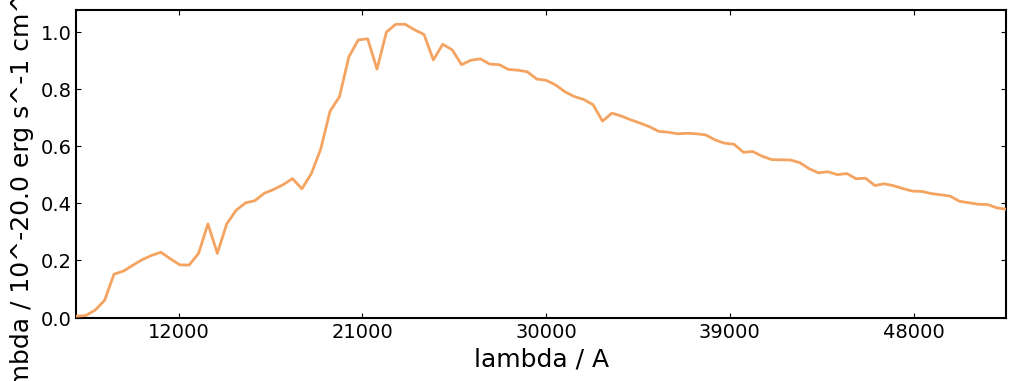

(<Figure size 1200x400 with 1 Axes>, [<Axes: xlabel='lambda / A', ylabel='f_lambda / 10^-20.0 erg s^-1 cm^-2 A^-1'>])


In [5]:
#What about model spectra
Resolution=100
ranges=(53000-7000)/Resolution

model = pipes.model_galaxy(model_components, spec_wavs=np.arange(7000., 53000., ranges))

fig = model.plot()
print(fig)
#fig[0].savefig("spec")
#dir(model)
#model.spectrum

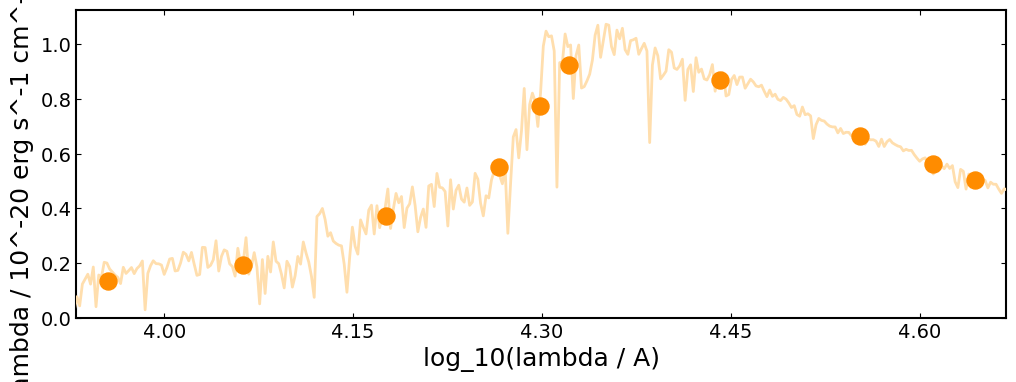

In [6]:
#what would we see in our filters?

model = pipes.model_galaxy(model_components, filt_list=filter_list)

fig=model.plot()

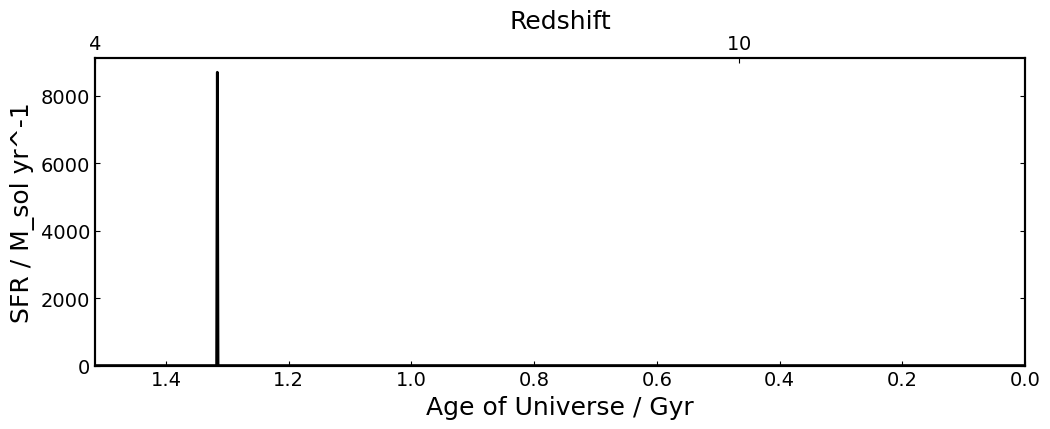

In [6]:
#What about the SFH?
fig = model.sfh.plot()

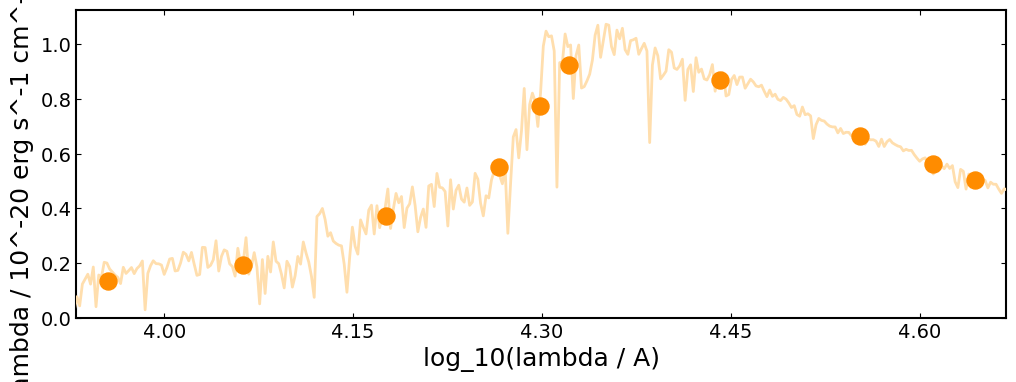

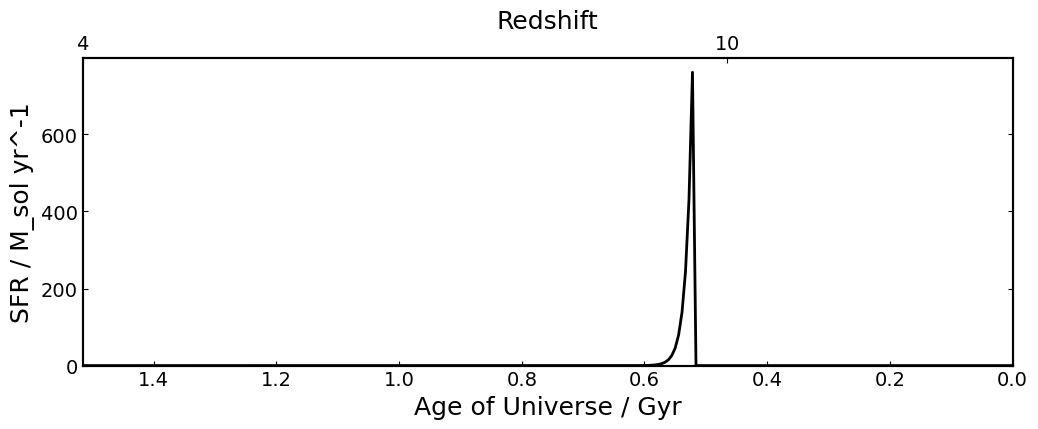

In [7]:
# #Can easily update our model
# exp["massformed"] = 10.           
# exp["tau"] = 1.5
# dust["Av"] = 1.0
# model_components["redshift"] = 0.5

# model.update(model_components)
fig=model.plot()
fig1 = model.sfh.plot()

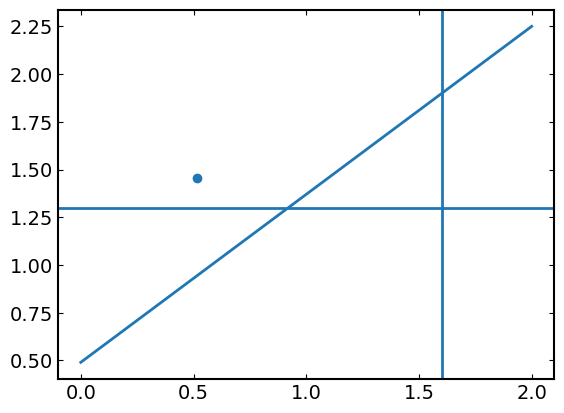

In [8]:
dir(model)

u,v, j=model.uvj


u-v, v-j
fig, ax=plt.subplots()
ax.scatter(v-j, u-v)
ax.axvline(1.6)
ax.axhline(1.3)
vjs=np.linspace(0,2)
ax.plot(vjs, 0.88 * vjs +0.49)





In [9]:
10000/6500


1.5384615384615385

In [10]:
model_components["redshift"]

4.0

In [11]:
dir(model)

['R',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_calculate_full_spectrum',
 '_calculate_photometry',
 '_calculate_spectrum',
 '_calculate_uvj_mags',
 '_get_R_curve_wav_sampling',
 '_get_index_spec_wavs',
 '_get_wavelength_sampling',
 'agn',
 'agn_dust_atten',
 'dust_atten',
 'dust_emission',
 'filt_list',
 'filter_set',
 'igm',
 'index_list',
 'line_fluxes',
 'lum_flux',
 'max_wavs',
 'model_comp',
 'nebular',
 'phot_units',
 'photometry',
 'plot',
 'plot_full_spectrum',
 'sfh',
 'spec_units',
 'spec_wavs',
 'spectrum_bc',
 'spectrum_full',
 'stellar',
 'update',
 'uvj',
 'uvj_filter_set',
 'waveleng

In [12]:
model.wavelengths


array([1.00000000e+00, 1.02500000e+00, 1.05062500e+00, ...,
       9.64007984e+07, 9.88108184e+07, 1.01281089e+08], shape=(1437,))

model.spec_wavs

In [13]:
model.spectrum_full

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       7.45060543e-33, 6.60420927e-33, 5.07368843e-36], shape=(1437,))

## 1.  Exploring model spectra and photometry

### Q1. Measure Dn4000 for the original model spectrum

Baseline Dn4000 = 1.3199


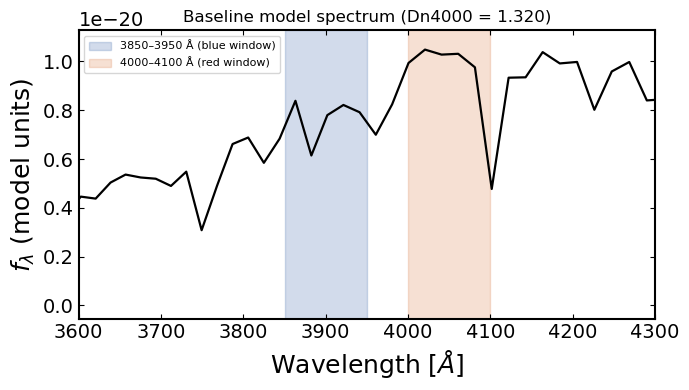

{'redshift': 4.0, 'exponential': {'age': 1.0, 'tau': 0.01, 'massformed': 10.0, 'metallicity': 0.5}, 'dust': {'type': 'Calzetti', 'Av': 0.1}}


In [14]:
# ==============================
# 1.1  Dn4000 Measurement
# ==============================

import numpy as np
import matplotlib.pyplot as plt

# --- Function to compute Dn4000 ---
def dn4000_from_model(model, blue=(3850,3950), red=(4000,4100), use_full=True):
    
    # Select spectrum
    if use_full and hasattr(model, "spectrum_full"):
        flux = model.spectrum_full
    else:
        flux = model.spectrum_bc if hasattr(model, "spectrum_bc") else model.spectrum

    wave = model.wavelengths

    b = (wave >= blue[0]) & (wave <= blue[1])
    r = (wave >= red[0]) & (wave <= red[1])

    if b.sum() < 3 or r.sum() < 3:
        raise ValueError("Not enough wavelength points in Dn4000 window.")

    return float(np.mean(flux[r]) / np.mean(flux[b]))

# --- Compute Dn4000 ---
Dn0 = dn4000_from_model(model)
print(f"Baseline Dn4000 = {Dn0:.4f}")

# --- Plot spectrum around break ---
wave = model.wavelengths
flux = model.spectrum_full if hasattr(model, "spectrum_full") else model.spectrum

plt.figure(figsize=(7,4))
plt.plot(wave, flux, lw=1.6, color="black")

# Blue window
plt.axvspan(
    3850, 3950,
    color="#4C72B0",   # soft blue
    alpha=0.25,
    label="3850–3950 Å (blue window)"
)

# Red window
plt.axvspan(
    4000, 4100,
    color="#DD8452",   # soft orange
    alpha=0.25,
    label="4000–4100 Å (red window)"
)

plt.xlim(3600, 4300)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"$f_\lambda$ (model units)")
plt.title(f"Baseline model spectrum (Dn4000 = {Dn0:.3f})")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(model.model_comp)

### Q2 — UVJ quiescence test for the baseline model

U, V, J = 6.594635879504722 5.139385798232825 4.62549844234373
U-V = 1.4552500812718971 V-J = 0.5138873558890946
Quiescent (UVJ)? True


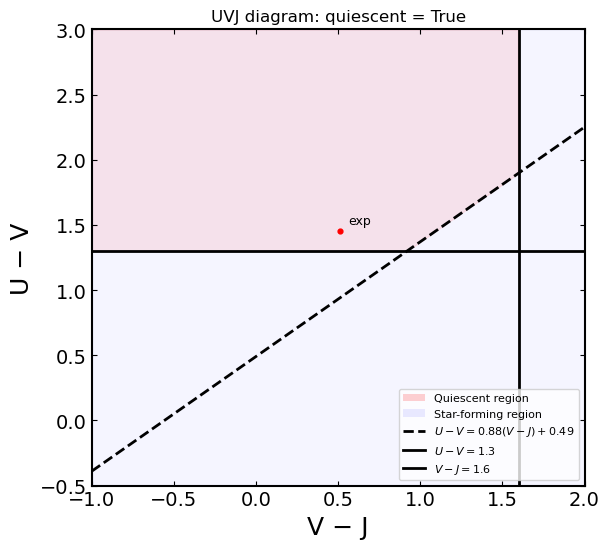

In [16]:
# ==============================
# 2.2 UVJ Classification Plot
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Get UVJ colours ---
U, V, J = model.uvj
UV = U - V
VJ = V - J

is_q = (UV > 0.88*VJ + 0.49) and (UV > 1.3) and (VJ < 1.6)

print("U, V, J =", U, V, J)
print("U-V =", UV, "V-J =", VJ)
print("Quiescent (UVJ)?", is_q)

# --- Dynamic axis limits ---
xmin = min(-1.0, VJ - 0.5)
xmax = max(2.0, VJ + 0.5)
ymin = min(-0.5, UV - 0.5)
ymax = max(3.0, UV + 0.5)

x = np.linspace(xmin, xmax, 400)

# UVJ boundaries
y_diag = 0.88 * x + 0.49
y_h = 1.3
x_v = 1.6

plt.figure(figsize=(6.2, 5.6))

# ==============================
# Shade regions
# ==============================

# --- Star-forming background (blue) ---
plt.fill_between(
    x, ymin, ymax,
    color="blue",
    alpha=0.04
)

# --- Quiescent region (red) ---
x_shade = x[x <= x_v]
y_lower = np.maximum(0.88 * x_shade + 0.49, y_h)

plt.fill_between(
    x_shade, y_lower, ymax,
    color="red",
    alpha=0.08
)

# ==============================
# Plot boundaries
# ==============================

# Diagonal (dashed)
plt.plot(
    x, y_diag,
    linestyle="--",
    linewidth=2,
    color="black",
    label=r"$U-V=0.88(V-J)+0.49$"
)

# Horizontal & vertical (solid)
plt.axhline(y_h, linewidth=2, color="black", label=r"$U-V=1.3$")
plt.axvline(x_v, linewidth=2, color="black", label=r"$V-J=1.6$")

# ==============================
# Galaxy point
# ==============================

plt.scatter(VJ, UV, s=12, color="red", zorder=5)
plt.text(VJ + 0.05, UV + 0.05, "exp", fontsize=9)

# ==============================
# Labels / legend
# ==============================

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.xlabel("V − J")
plt.ylabel("U − V")
plt.title(f"UVJ diagram: quiescent = {is_q}")

region_handles = [
    Patch(facecolor="red", alpha=0.18, label="Quiescent region"),
    Patch(facecolor="blue", alpha=0.08, label="Star-forming region"),
]

line_handles, line_labels = plt.gca().get_legend_handles_labels()

plt.legend(
    handles=region_handles + line_handles,
    loc="lower right",
    fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.show()

###  Q3 — increase dust A_V: 0.1 -> 2.0

=== Exponential (Av=0.1) ===
Dn4000 = 1.3285764346514755
U,V,J  = (6.591999302529555, 5.132913938949719, 4.624530489517013)
U-V = 1.4590853635798355  V-J = 0.5083834494327064
Quiescent (UVJ)? True

=== Dusty (Av=2.0) ===
Dn4000 = 1.4378280174800129
U,V,J  = (9.390939225229747, 7.023367361283532, 5.243619358035919)
U-V = 2.367571863946215  V-J = 1.7797480032476134
Quiescent (UVJ)? False


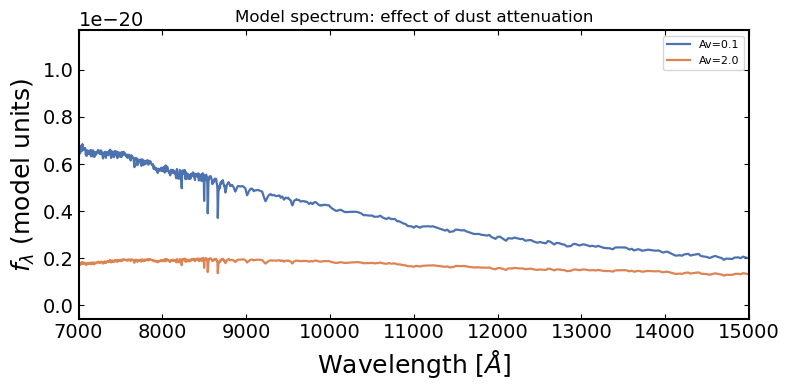

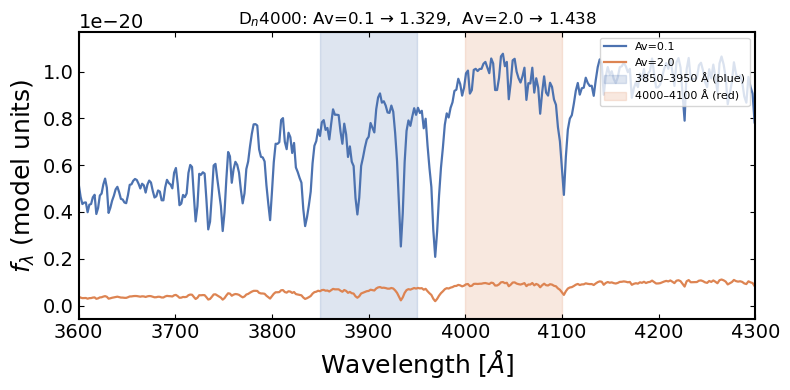

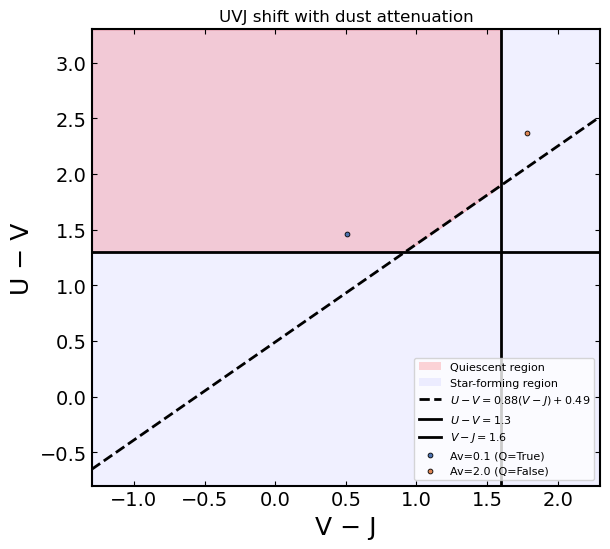

In [17]:
# ==============================
# 1.3  Dust test: Av=0.1 -> 2.0
# (consistent plotting style)
# ==============================

import numpy as np
import copy
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------- Helper: Dn4000 ----------
def dn4000_from_model(model, blue=(3850,3950), red=(4000,4100), use_full=True):
    wave = np.asarray(model.wavelengths)
    if use_full and hasattr(model, "spectrum_full"):
        flux = np.asarray(model.spectrum_full)
    else:
        flux = np.asarray(model.spectrum_bc if hasattr(model, "spectrum_bc") else model.spectrum)

    b = (wave >= blue[0]) & (wave <= blue[1])
    r = (wave >= red[0]) & (wave <= red[1])

    if b.sum() < 3 or r.sum() < 3:
        raise ValueError(
            f"Not enough points in Dn4000 windows: blue={b.sum()} red={r.sum()}. "
            "Increase spec_wavs sampling near 4000A."
        )
    return float(np.mean(flux[r]) / np.mean(flux[b]))

# ---------- Helper: UVJ + quiescent flag ----------
def uvj_from_model(model):
    U, V, J = model.uvj
    UV = float(U - V)
    VJ = float(V - J)
    is_q = (UV > 0.88*VJ + 0.49) and (UV > 1.3) and (VJ < 1.6)
    return UV, VJ, bool(is_q), (float(U), float(V), float(J))

# ---------- Ensure good sampling near 4000A ----------
spec_wavs = np.unique(np.concatenate([
    np.arange(7000., 53000., 50.),   # global sampling
    np.arange(3500., 4500., 1.0)     # fine sampling around the 4000A break
]))

# ---------- Baseline model (Av=0.1) ----------
model_base = pipes.model_galaxy(model_components, spec_wavs=spec_wavs)
Dn0 = dn4000_from_model(model_base)
UV0, VJ0, isq0, mags0 = uvj_from_model(model_base)

print("=== Exponential (Av=0.1) ===")
print("Dn4000 =", Dn0)
print("U,V,J  =", mags0)
print("U-V =", UV0, " V-J =", VJ0)
print("Quiescent (UVJ)?", isq0)

# ---------- Dusty model (Av=2.0) ----------
model_components_dust = copy.deepcopy(model_components)
model_components_dust["dust"]["Av"] = 2.0

model_dust = pipes.model_galaxy(model_components_dust, spec_wavs=spec_wavs)
Dn2 = dn4000_from_model(model_dust)
UV2, VJ2, isq2, mags2 = uvj_from_model(model_dust)

print("\n=== Dusty (Av=2.0) ===")
print("Dn4000 =", Dn2)
print("U,V,J  =", mags2)
print("U-V =", UV2, " V-J =", VJ2)
print("Quiescent (UVJ)?", isq2)

# ==============================
# Plot 1: wide spectrum
# ==============================

plt.figure(figsize=(8,4))
plt.plot(model_base.wavelengths, model_base.spectrum_full, lw=1.6, color="#4C72B0", label="Av=0.1")
plt.plot(model_dust.wavelengths, model_dust.spectrum_full, lw=1.6, color="#DD8452", label="Av=2.0")

plt.xlim(7000, 15000)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"$f_\lambda$ (model units)")
plt.title("Model spectrum: effect of dust attenuation")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ==============================
# Plot 2: zoom around 4000A + coloured windows
# ==============================

plt.figure(figsize=(8,4))
plt.plot(model_base.wavelengths, model_base.spectrum_full, lw=1.6, color="#4C72B0", label="Av=0.1")
plt.plot(model_dust.wavelengths, model_dust.spectrum_full, lw=1.6, color="#DD8452", label="Av=2.0")

# coloured Dn4000 windows (match 1.1)
plt.axvspan(3850, 3950, color="#4C72B0", alpha=0.18, label="3850–3950 Å (blue)")
plt.axvspan(4000, 4100, color="#DD8452", alpha=0.18, label="4000–4100 Å (red)")

plt.xlim(3600, 4300)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"$f_\lambda$ (model units)")
plt.title(f"D$_n$4000: Av=0.1 → {Dn0:.3f},  Av=2.0 → {Dn2:.3f}")
plt.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

# ==============================
# Plot 3: UVJ diagram with shaded regions + both points
# ==============================

# Dynamic axes that include both points
xmin = min(-1.0, VJ0, VJ2) - 0.3
xmax = max(2.0,  VJ0, VJ2) + 0.3
ymin = min(-0.5, UV0, UV2) - 0.3
ymax = max(3.0,  UV0, UV2) + 0.3

x = np.linspace(xmin, xmax, 400)

y_diag = 0.88 * x + 0.49
y_h = 1.3
x_v = 1.6

plt.figure(figsize=(6.2, 5.6))

# star-forming background
plt.fill_between(x, ymin, ymax, color="blue", alpha=0.06)

# quiescent wedge
x_shade = x[x <= x_v]
y_lower = np.maximum(0.88 * x_shade + 0.49, y_h)
plt.fill_between(x_shade, y_lower, ymax, color="red", alpha=0.16)

# boundaries
plt.plot(x, y_diag, linestyle="--", linewidth=2, color="black", label=r"$U-V=0.88(V-J)+0.49$")
plt.axhline(y_h, linewidth=2, color="black", label=r"$U-V=1.3$")
plt.axvline(x_v, linewidth=2, color="black", label=r"$V-J=1.6$")

# points
plt.scatter(VJ0, UV0, s=12, color="#4C72B0", edgecolor="black", linewidth=0.6, zorder=5,
            label=f"Av=0.1 (Q={isq0})")
plt.scatter(VJ2, UV2, s=12, color="#DD8452", edgecolor="black", linewidth=0.6, zorder=5,
            label=f"Av=2.0 (Q={isq2})")

# labels
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.xlabel("V − J")
plt.ylabel("U − V")
plt.title("UVJ shift with dust attenuation")

# legend: region patches + lines + points
region_handles = [
    Patch(facecolor="red", alpha=0.16, label="Quiescent region"),
    Patch(facecolor="blue", alpha=0.06, label="Star-forming region"),
]
line_handles, line_labels = plt.gca().get_legend_handles_labels()

plt.legend(handles=region_handles + line_handles, loc="lower right", fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

### Q4. vary SFH prescriptions (burst, double power law, delayed) at Av=0.1

SFH comparison (Av=0.1):
SFH		Dn4000		U-V		V-J		UVJ-quiescent
burst           1.043		  0.787		 -0.111		False
doublepowerlaw  1.049		  0.608		  0.359		False
delayed         0.915		 -0.307		 -0.881		False
burst U,V,J = [4.57542111 3.78831687 3.89957284] U-V = 0.7871042325501905 V-J = -0.11125596831782314
doublepowerlaw U,V,J = [4.95738586 4.34987609 3.99064808] U-V = 0.6075097660121829 V-J = 0.35922801380150426
delayed U,V,J = [3.70789983 4.01525323 4.89630492] U-V = -0.30735340326009153 V-J = -0.8810516855858044


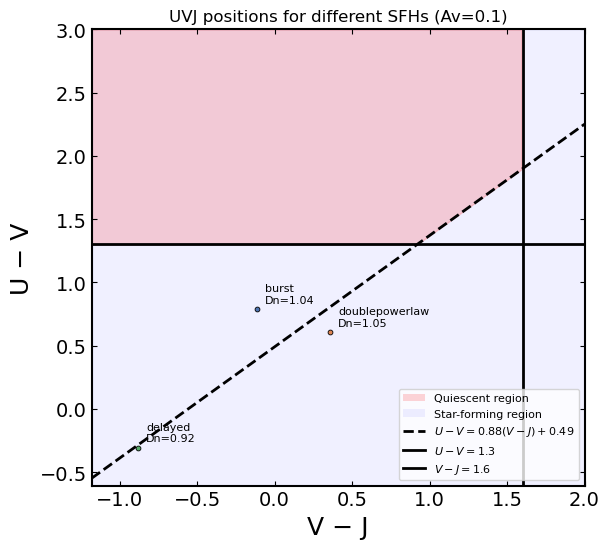

In [18]:
import numpy as np
import copy
import matplotlib.pyplot as plt

# ---------- High-res wavelength grid (needed for Dn4000) ----------
spec_wavs = np.unique(np.concatenate([
    np.arange(7000., 53000., 50.0),
    np.arange(3500., 4500., 1.0)
]))

# ---------- Helpers ----------
def dn4000_from_model(model, blue=(3850,3950), red=(4000,4100)):
    wave = np.asarray(model.wavelengths)
    flux = np.asarray(model.spectrum_full if hasattr(model, "spectrum_full") else model.spectrum)
    b = (wave >= blue[0]) & (wave <= blue[1])
    r = (wave >= red[0]) & (wave <= red[1])
    if b.sum() < 3 or r.sum() < 3:
        raise ValueError("Not enough points near 4000A. Use the high-res spec_wavs grid.")
    return float(np.mean(flux[r]) / np.mean(flux[b]))

def uvj_from_model(model):
    U, V, J = model.uvj
    UV = float(U - V)
    VJ = float(V - J)
    is_q = (UV > 0.88*VJ + 0.49) and (UV > 1.3) and (VJ < 1.6)
    return UV, VJ, bool(is_q)

# ---------- Fixed components (copied from the PROVIDED cell values) ----------
z_obs = 4.0

nebular = {"logU": -2.5}

dust_fixed = {"type": "Calzetti", "Av": 0.1}

# SFH dictionaries copied from your provided model-building cell:
burst = {
    "age": 0.2,
    "massformed": 10.0,
    "metallicity": 0.1,
    "nebular": nebular,
    "t_bc": 0.02
}

dblplaw = {
    "tau": 0.75,
    "alpha": 0.2,
    "beta": 0.4,
    "massformed": 10.0,
    "metallicity": 1.2
}

delayed = {
    "tau": 0.1,
    "age": 0.01,
    "massformed": 9.0,
    "metallicity": 0.02
}

def build_model_components(sfh_key, sfh_dict):
    mc = {"redshift": z_obs, "dust": copy.deepcopy(dust_fixed)}
    mc[sfh_key] = copy.deepcopy(sfh_dict)
    return mc

sfh_cases = [
    ("burst", "burst", burst),
    ("doublepowerlaw", "dblplaw", dblplaw),
    ("delayed", "delayed", delayed),
]

results = []
models = {}

for label, key, sfh_dict in sfh_cases:
    mc = build_model_components(key, sfh_dict)
    m = pipes.model_galaxy(mc, spec_wavs=spec_wavs)
    Dn = dn4000_from_model(m)
    UV, VJ, is_q = uvj_from_model(m)
    results.append((label, Dn, UV, VJ, is_q))
    models[label] = m

# ---------- Print table ----------
print("SFH comparison (Av=0.1):")
print("SFH\t\tDn4000\t\tU-V\t\tV-J\t\tUVJ-quiescent")
for label, Dn, UV, VJ, is_q in results:
    print(f"{label:14s}{Dn:7.3f}\t\t{UV:7.3f}\t\t{VJ:7.3f}\t\t{is_q}")

# -------- Quick sanity check --------
for label in ["burst", "doublepowerlaw", "delayed"]:
    m = models[label]
    print(label, "U,V,J =", m.uvj, "U-V =", m.uvj[0]-m.uvj[1], "V-J =", m.uvj[1]-m.uvj[2])
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt

# ---------- UVJ plot with shaded regions (consistent style) ----------
# results is: (label, Dn, UV, VJ, is_q)

# Collect points
vjs = np.array([VJ for (_, _, _, VJ, _) in results])
uvs = np.array([UV for (_, _, UV, _, _) in results])

# Dynamic axes (include all points nicely)
xmin = min(-1.0, vjs.min() - 0.3)
xmax = max(2.0,  vjs.max() + 0.3)
ymin = min(-0.5, uvs.min() - 0.3)
ymax = max(3.0,  uvs.max() + 0.3)

x = np.linspace(xmin, xmax, 400)

# UVJ boundaries
y_diag = 0.88 * x + 0.49
y_h = 1.3
x_v = 1.6

plt.figure(figsize=(6.2, 5.6))

# --- Shade star-forming background ---
plt.fill_between(x, ymin, ymax, color="blue", alpha=0.06)

# --- Shade quiescent wedge ---
x_shade = x[x <= x_v]
y_lower = np.maximum(0.88 * x_shade + 0.49, y_h)
plt.fill_between(x_shade, y_lower, ymax, color="red", alpha=0.16)

# --- Boundary lines (match style from 1.2/1.3) ---
plt.plot(x, y_diag, linestyle="--", linewidth=2, color="black",
         label=r"$U-V=0.88(V-J)+0.49$")
plt.axhline(y_h, linewidth=2, color="black", label=r"$U-V=1.3$")
plt.axvline(x_v, linewidth=2, color="black", label=r"$V-J=1.6$")

# --- Points: consistent colours + black edge ---
# pick distinct colours for the three SFHs (matches your earlier plot)
color_map = {
    "burst": "#4C72B0",          # blue
    "doublepowerlaw": "#DD8452", # orange
    "delayed": "#55A868"         # green
}

for label, Dn, UV, VJ, is_q in results:
    c = color_map.get(label, "gray")
    plt.scatter(VJ, UV, s=12, color=c, edgecolor="black", linewidth=0.6, zorder=5)
    plt.text(VJ + 0.05, UV + 0.05, f"{label}\nDn={Dn:.2f}", fontsize=8)

# --- Labels / limits ---
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.xlabel("V − J")
plt.ylabel("U − V")
plt.title("UVJ positions for different SFHs (Av=0.1)")

# --- Legend: region patches + boundary lines ---
region_handles = [
    Patch(facecolor="red", alpha=0.16, label="Quiescent region"),
    Patch(facecolor="blue", alpha=0.06, label="Star-forming region"),
]
line_handles, line_labels = plt.gca().get_legend_handles_labels()

plt.legend(handles=region_handles + line_handles,
           loc="lower right", fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

# 2 Exploring real JWST data

### 2.0 Load the spectrum and photometry files


Filename: gds-barrufet-s67-v3_prism-clear_2198_8290.spec.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SPEC1D        1 BinTableHDU    352   435R x 10C   [D, D, D, D, D, D, D, D, D, D]   
  2  SCI           1 ImageHDU       327   (435, 31)   float64   
  3  WHT           1 ImageHDU       327   (435, 31)   float64   
  4  PROFILE       1 ImageHDU       327   (435, 31)   float64   
  5  PROF1D        1 BinTableHDU     25   31R x 3C   [D, D, D]   
  6  BACKGROUND    1 ImageHDU       327   (435, 31)   float64   
  7  SLITS         1 BinTableHDU    103   3R x 47C   [54A, K, K, D, D, D, D, D, K, 9A, D, D, D, D, 3A, K, K, D, D, K, K, K, K, K, K, K, 4A, 5A, 5A, 25A, K, K, D, K, K, K, 12A, D, D, D, D, 17A, K, 4A, K, D, D]   

--- Spectrum ---
Flux units converted to nJy
Wavelength range [Å]: 6157.725852112719 – 52941.360353656055
Median Fν (nJy): 1069.0506339371464
Filename: photometry/8290_photometry.fits
No.    Name  

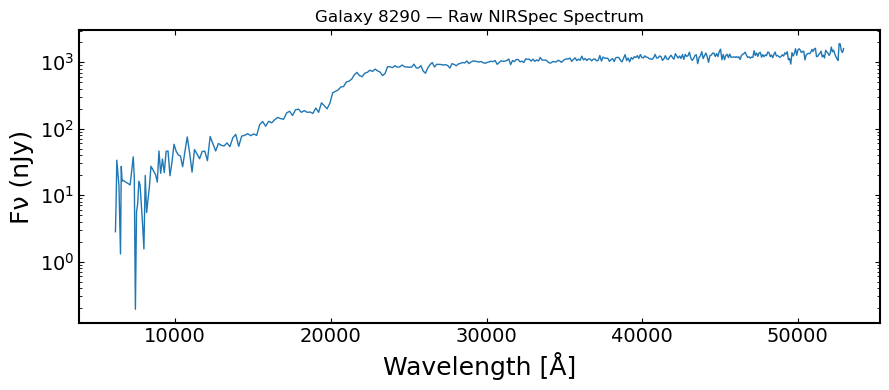

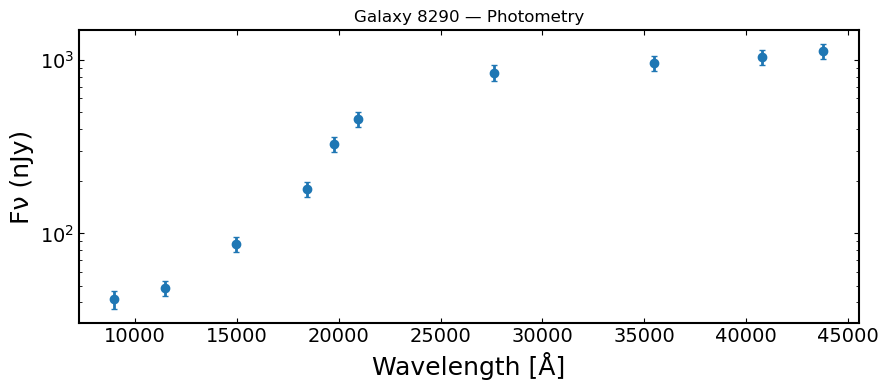

In [21]:
# ============================================================
# 2.0  Load and inspect NIRSpec spectrum + photometry
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# -----------------------------
# Load 1D NIRSpec spectrum
# -----------------------------
spec_path = "gds-barrufet-s67-v3_prism-clear_2198_8290.spec.fits"

with fits.open(spec_path) as hdul:
    hdul.info()
    spec_data = hdul["SPEC1D"].data
    spec_header = hdul["SPEC1D"].header

# Extract columns
wave = np.array(spec_data["wave"])
fnu_spec_uJy = np.array(spec_data["flux"])
enu_spec_uJy = np.array(spec_data["err"])

# Convert spectrum from μJy → nJy
fnu_spec = fnu_spec_uJy * 1000
enu_spec = enu_spec_uJy * 1000

# Ensure wavelength in Angstrom
wave_A = wave.copy()
if np.nanmax(wave_A) < 100:   # likely microns
    wave_A *= 1e4

# Mask bad values
good_spec = (
    np.isfinite(wave_A)
    & np.isfinite(fnu_spec)
    & np.isfinite(enu_spec)
    & (fnu_spec > 0)
)

wave_A = wave_A[good_spec]
fnu_spec = fnu_spec[good_spec]
enu_spec = enu_spec[good_spec]

print("\n--- Spectrum ---")
print("Flux units converted to nJy")
print("Wavelength range [Å]:", wave_A.min(), "–", wave_A.max())
print("Median Fν (nJy):", np.nanmedian(fnu_spec))


# -----------------------------
# Load photometry
# -----------------------------
phot_path = "photometry/8290_photometry.fits"

with fits.open(phot_path) as ph:
    ph.info()
    tab = ph[1].data

lam_ph_A = np.array(tab["wavelength"])
fnu_ph_njy = np.array(tab["mags_obs"])        # flux density in nJy
enu_ph_njy = np.array(tab["mags_unc_obs"])    # uncertainty in nJy

# Mask invalid points
good_ph = (
    np.isfinite(lam_ph_A)
    & np.isfinite(fnu_ph_njy)
    & np.isfinite(enu_ph_njy)
    & (fnu_ph_njy > 0)
)

lam_ph_A = lam_ph_A[good_ph]
fnu_ph_njy = fnu_ph_njy[good_ph]
enu_ph_njy = enu_ph_njy[good_ph]

print("\n--- Photometry ---")
print("Flux units: nJy")
print("Phot λ range [Å]:", lam_ph_A.min(), "–", lam_ph_A.max())
print("Median Fν (nJy):", np.nanmedian(fnu_ph_njy))


# -----------------------------
# Quick inspection plots
# -----------------------------

# Spectrum
plt.figure(figsize=(9,4))
plt.plot(wave_A, fnu_spec, lw=1)
plt.xlabel("Wavelength [Å]")
plt.ylabel("Fν (nJy)")
plt.title("Galaxy 8290 — Raw NIRSpec Spectrum")
plt.yscale("log")
plt.tight_layout()
plt.show()

# Photometry
plt.figure(figsize=(9,4))
plt.errorbar(
    lam_ph_A,
    fnu_ph_njy,
    yerr=enu_ph_njy,
    fmt="o",
    capsize=2
)
plt.xlabel("Wavelength [Å]")
plt.ylabel("Fν (nJy)")
plt.title("Galaxy 8290 — Photometry")
plt.yscale("log")
plt.tight_layout()
plt.show()

### 2.1 Convert to Fλ 

Converted to Fλ in cgs using: spectrum=nJy, photometry=nJy
Median Fλ spectrum [cgs/Å]: 1.947411211074761e-20
Median Fλ phot    [cgs/Å]: 1.82237226943156e-20
Median ratio phot/spec: 0.9357922246045851


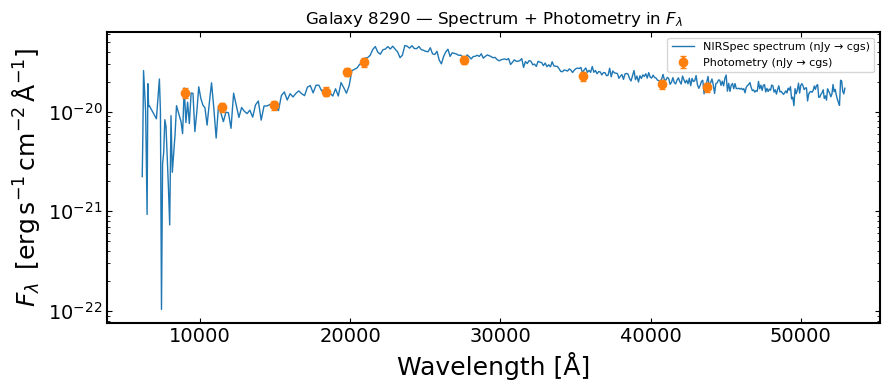

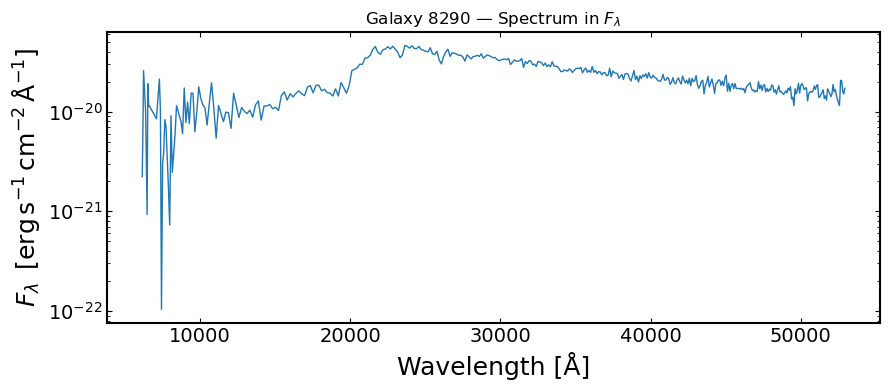

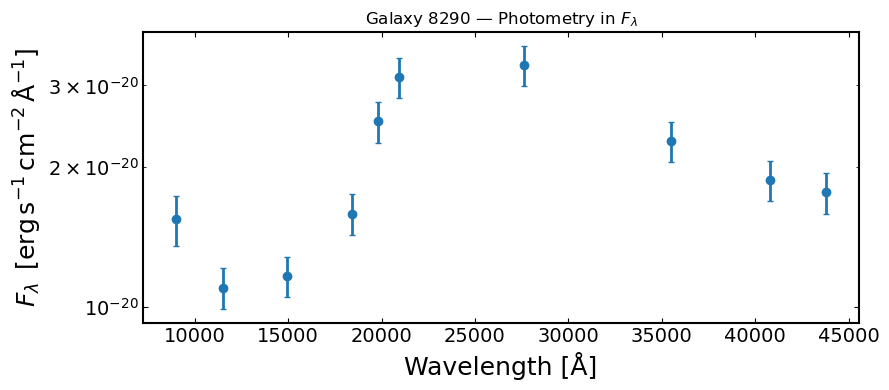

In [23]:
# ============================================================
# 2.1  Convert spectrum + photometry from Fnu to Flam (cgs)
#      Here BOTH spectrum and photometry are already in nJy
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

c_A_s = 2.99792458e18  # speed of light [Å/s]

# -----------------------------
# Spectrum: nJy -> cgs
# -----------------------------
# 1 nJy = 1e-32 erg s^-1 cm^-2 Hz^-1
fnu_spec_cgs = fnu_spec * 1e-32
enu_spec_cgs = enu_spec * 1e-32

flam_spec = fnu_spec_cgs * c_A_s / (wave_A**2)
elam_spec = enu_spec_cgs * c_A_s / (wave_A**2)

# -----------------------------
# Photometry: nJy -> cgs
# -----------------------------
fnu_ph_cgs = fnu_ph_njy * 1e-32
enu_ph_cgs = enu_ph_njy * 1e-32

flam_ph = fnu_ph_cgs * c_A_s / (lam_ph_A**2)
elam_ph = enu_ph_cgs * c_A_s / (lam_ph_A**2)

print("Converted to Fλ in cgs using: spectrum=nJy, photometry=nJy")
print("Median Fλ spectrum [cgs/Å]:", np.nanmedian(flam_spec))
print("Median Fλ phot    [cgs/Å]:", np.nanmedian(flam_ph))
print("Median ratio phot/spec:", np.nanmedian(flam_ph) / np.nanmedian(flam_spec))

# -----------------------------
# Plot: spectrum + photometry together in Fλ
# -----------------------------
plt.figure(figsize=(9,4))
plt.plot(wave_A, flam_spec, lw=1, label="NIRSpec spectrum (nJy → cgs)")
plt.errorbar(
    lam_ph_A, flam_ph, yerr=elam_ph,
    fmt="o", capsize=2,
    label="Photometry (nJy → cgs)"
)

plt.yscale("log")
plt.xlabel("Wavelength [Å]")
plt.ylabel(r"$F_\lambda\ \,[\mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}]$")
plt.title("Galaxy 8290 — Spectrum + Photometry in $F_\\lambda$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# -----------------------------
# Optional separate plots
# -----------------------------
plt.figure(figsize=(9,4))
plt.plot(wave_A, flam_spec, lw=1)
plt.yscale("log")
plt.xlabel("Wavelength [Å]")
plt.ylabel(r"$F_\lambda\ \,[\mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}]$")
plt.title("Galaxy 8290 — Spectrum in $F_\\lambda$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.errorbar(lam_ph_A, flam_ph, yerr=elam_ph, fmt="o", capsize=2)
plt.yscale("log")
plt.xlabel("Wavelength [Å]")
plt.ylabel(r"$F_\lambda\ \,[\mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}]$")
plt.title("Galaxy 8290 — Photometry in $F_\\lambda$")
plt.tight_layout()
plt.show()

### 2.2 Redshift estimation

=== Balmer-break redshift estimate (using Fλ) ===
Spectrum:   z_best = 4.515   (peak region ~ 4.385–4.670)
Photometry: z_best = 4.350   (peak region ~ 4.350–4.490)
Using z_show = 4.350 -> Balmer break at λ_obs ≈ 19506 Å
Slide reference (given by you): z ≈ 4.360 -> λ_obs ≈ 19543 Å


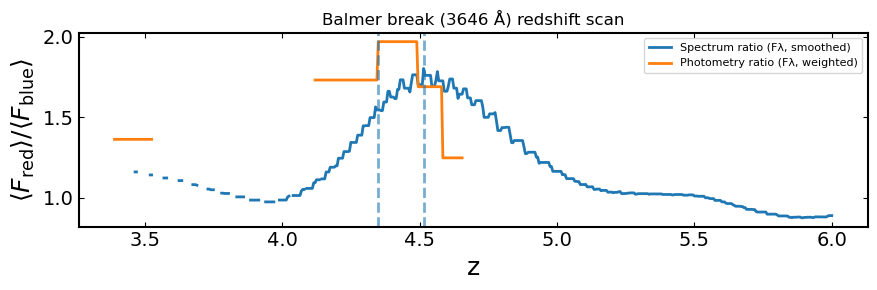

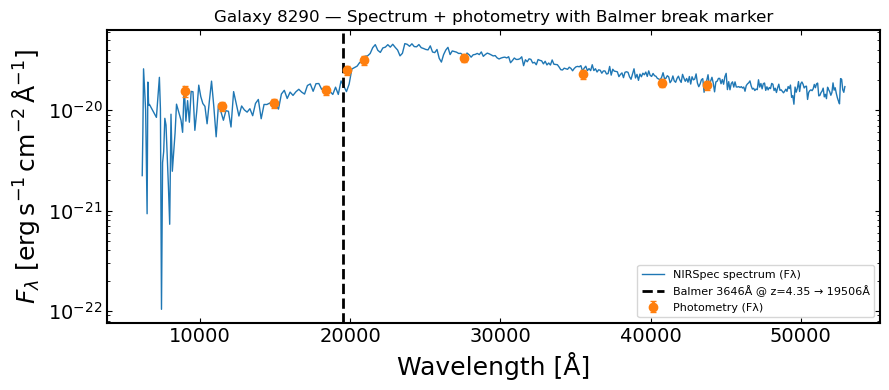

In [24]:
import numpy as np
import matplotlib.pyplot as plt

BALMER_REST = 3646.0  # Å

# ---- Preconditions from 2.1 ----
needed = ["wave_A", "flam_spec", "elam_spec", "lam_ph_A", "flam_ph", "elam_ph"]
missing = [k for k in needed if k not in globals()]
if missing:
    raise NameError(f"Missing variables from 2.1: {missing}. Run Section 2.1 first.")


def boxcar_smooth(y, n=9):
    y = np.asarray(y, dtype=float)
    if n is None or n <= 1:
        return y
    k = np.ones(int(n), dtype=float)/float(n)
    return np.convolve(y, k, mode="same")


# ---------- Spectrum ratio (UNWEIGHTED, robust) ----------
def balmer_ratio_spec(wave_obs, flam, z,
                      blue=(3450,3630), red=(3680,3900),
                      smooth_pts=9, min_pts=5):
    f = boxcar_smooth(flam, smooth_pts)
    b0, b1 = (1+z)*blue[0], (1+z)*blue[1]
    r0, r1 = (1+z)*red[0],  (1+z)*red[1]

    mb = (wave_obs >= b0) & (wave_obs <= b1) & np.isfinite(f) & (f > 0)
    mr = (wave_obs >= r0) & (wave_obs <= r1) & np.isfinite(f) & (f > 0)

    if mb.sum() < min_pts or mr.sum() < min_pts:
        return np.nan

    Fb = np.nanmean(f[mb])
    Fr = np.nanmean(f[mr])
    if not np.isfinite(Fb) or Fb <= 0 or not np.isfinite(Fr):
        return np.nan
    return Fr/Fb


# ---------- Photometry ratio (WEIGHTED, sparse-safe) ----------
def wmean(x, w):
    x = np.asarray(x, float); w = np.asarray(w, float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if m.sum() == 0:
        return np.nan
    return np.sum(w[m]*x[m]) / np.sum(w[m])

def balmer_ratio_phot(wave_obs, flam, eflam, z,
                      blue=(3300,3600), red=(3700,4200),
                      min_pts=1):
    b0, b1 = (1+z)*blue[0], (1+z)*blue[1]
    r0, r1 = (1+z)*red[0],  (1+z)*red[1]

    mb = (wave_obs >= b0) & (wave_obs <= b1) & np.isfinite(flam) & np.isfinite(eflam) & (eflam > 0)
    mr = (wave_obs >= r0) & (wave_obs <= r1) & np.isfinite(flam) & np.isfinite(eflam) & (eflam > 0)

    if mb.sum() < min_pts or mr.sum() < min_pts:
        return np.nan

    wb = 1.0/eflam[mb]**2
    wr = 1.0/eflam[mr]**2
    Fb = wmean(flam[mb], wb)
    Fr = wmean(flam[mr], wr)
    if not np.isfinite(Fb) or Fb <= 0 or not np.isfinite(Fr):
        return np.nan
    return Fr/Fb


def scan(func, zmin=2.0, zmax=6.0, ngrid=801):
    zgrid = np.linspace(zmin, zmax, ngrid)
    vals = np.array([func(z) for z in zgrid], dtype=float)
    if np.all(np.isnan(vals)):
        return np.nan, (np.nan, np.nan), zgrid, vals
    zbest = zgrid[np.nanargmax(vals)]
    vmax = np.nanmax(vals)
    m = np.isfinite(vals) & (vals >= 0.9*vmax)
    zlo = float(np.min(zgrid[m])) if np.any(m) else np.nan
    zhi = float(np.max(zgrid[m])) if np.any(m) else np.nan
    return float(zbest), (zlo, zhi), zgrid, vals


# Run scans
z_best_spec, z_rng_spec, zgrid, Rspec = scan(lambda z: balmer_ratio_spec(wave_A, flam_spec, z))
z_best_phot, z_rng_phot, _,    Rphot = scan(lambda z: balmer_ratio_phot(lam_ph_A, flam_ph, elam_ph, z))

print("=== Balmer-break redshift estimate (using Fλ) ===")
print(f"Spectrum:   z_best = {z_best_spec:.3f}   (peak region ~ {z_rng_spec[0]:.3f}–{z_rng_spec[1]:.3f})")
if np.isfinite(z_best_phot):
    print(f"Photometry: z_best = {z_best_phot:.3f}   (peak region ~ {z_rng_phot[0]:.3f}–{z_rng_phot[1]:.3f})")
else:
    print("Photometry: z_best = NaN (expected if no points fall in the windows).")

# choose z_show: prefer photometry if spectrum fails
z_show = z_best_phot if np.isfinite(z_best_phot) else z_best_spec
lam_break_obs = BALMER_REST*(1+z_show)

print(f"Using z_show = {z_show:.3f} -> Balmer break at λ_obs ≈ {lam_break_obs:.0f} Å")
print("Slide reference (given by you): z ≈ 4.360 -> λ_obs ≈", f"{BALMER_REST*(1+4.360):.0f} Å")

# Plot scan
plt.figure(figsize=(9,3))
plt.plot(zgrid, Rspec, label="Spectrum ratio (Fλ, smoothed)")
plt.plot(zgrid, Rphot, label="Photometry ratio (Fλ, weighted)")
if np.isfinite(z_best_spec): plt.axvline(z_best_spec, ls="--", alpha=0.6)
if np.isfinite(z_best_phot): plt.axvline(z_best_phot, ls="--", alpha=0.6)
plt.xlabel("z")
plt.ylabel(r"$\langle F_{\rm red}\rangle / \langle F_{\rm blue}\rangle$")
plt.title("Balmer break (3646 Å) redshift scan")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Plot data with break marker
plt.figure(figsize=(9,4))
plt.plot(wave_A, flam_spec, lw=1, label="NIRSpec spectrum (Fλ)")
plt.errorbar(lam_ph_A, flam_ph, yerr=elam_ph, fmt="o", capsize=2, label="Photometry (Fλ)")
plt.axvline(lam_break_obs, ls="--", color="k",
            label=f"Balmer 3646Å @ z={z_show:.2f} → {lam_break_obs:.0f}Å")
plt.yscale("log")
plt.xlabel("Wavelength [Å]")
plt.ylabel(r"$F_\lambda\ [\mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}]$")
plt.title("Galaxy 8290 — Spectrum + photometry with Balmer break marker")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 2.3 Plot the spectrum and photometry in the same figure

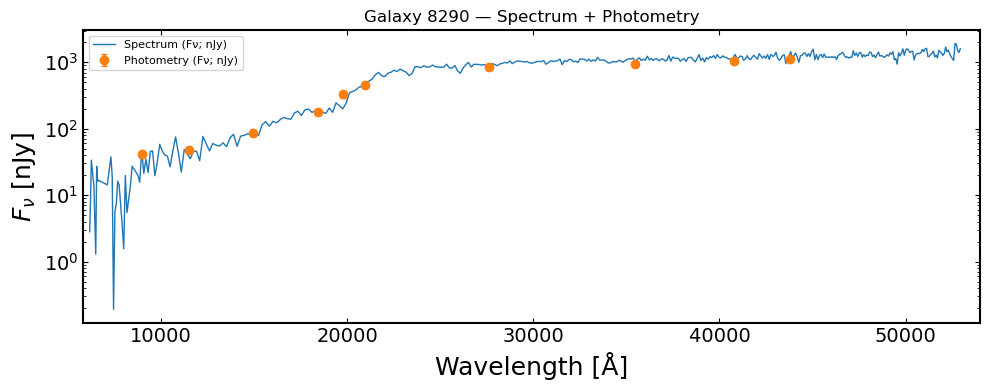

=== Spectrum vs photometry comparison ===
Overlap λ-range: 9000–45000 Å  (N=9 phot points)
Median phot/spec ratio: 1.002
Scatter in log10(phot/spec): ~0.054 dex


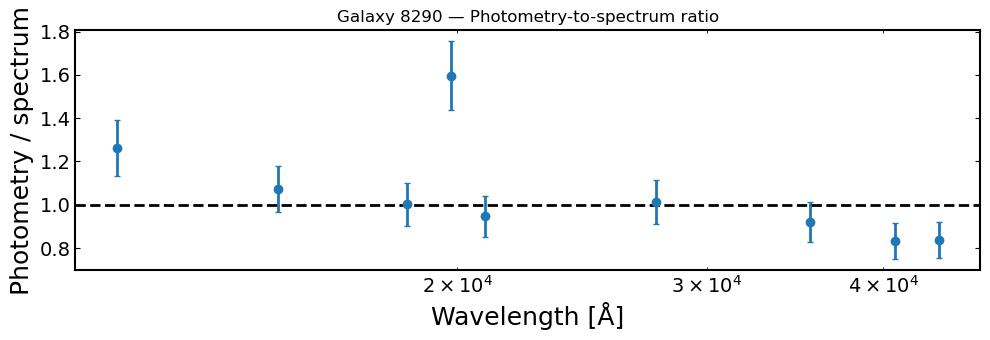


Interpretation:
- After putting both datasets in the same units (nJy), the spectrum and photometry agree well overall.
- The median photometry/spectrum ratio is close to 1, so there is no strong absolute offset.
- Small residual differences can still arise from:
  (i) slit/aperture losses or extraction differences,
  (ii) absolute flux calibration uncertainties,
  (iii) filter bandpass averaging vs monochromatic spectral sampling,
  (iv) noise/systematics, especially at the blue end of the prism spectrum.


In [26]:
# ============================================================
# 2.3  Plot spectrum + photometry together: do they agree?
#      Both datasets are already in nJy.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# --- inputs (already in nJy) ---
w_spec = np.asarray(wave_A, dtype=float)        # Å
f_spec = np.asarray(fnu_spec, dtype=float)      # nJy
e_spec = np.asarray(enu_spec, dtype=float)      # nJy

w_ph   = np.asarray(lam_ph_A, dtype=float)      # Å
f_ph   = np.asarray(fnu_ph_njy, dtype=float)    # nJy
e_ph   = np.asarray(enu_ph_njy, dtype=float)    # nJy

# --- masks ---
m_spec = np.isfinite(w_spec) & np.isfinite(f_spec) & np.isfinite(e_spec) & (f_spec > 0) & (e_spec > 0)
m_ph   = np.isfinite(w_ph)   & np.isfinite(f_ph)   & np.isfinite(e_ph)   & (f_ph > 0)   & (e_ph > 0)

w_spec, f_spec, e_spec = w_spec[m_spec], f_spec[m_spec], e_spec[m_spec]
w_ph,   f_ph,   e_ph   = w_ph[m_ph],     f_ph[m_ph],     e_ph[m_ph]

# ------------------------------------------------------------
# Plot A: direct overlay in the same units
# ------------------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(w_spec, f_spec, lw=1, label="Spectrum (Fν; nJy)")
plt.errorbar(w_ph, f_ph, yerr=e_ph, fmt="o", capsize=2, label="Photometry (Fν; nJy)")
plt.yscale("log")
plt.xlim(5800, 54000)
plt.xlabel("Wavelength [Å]")
plt.ylabel(r"$F_\nu$ [nJy]")
plt.title("Galaxy 8290 — Spectrum + Photometry")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Quantify agreement in overlap region
# ------------------------------------------------------------
lo, hi = 9000.0, 45000.0

# interpolate spectrum onto photometric wavelengths
spec_on_ph = np.interp(w_ph, w_spec, f_spec)

m = (
    (w_ph >= lo) & (w_ph <= hi) &
    np.isfinite(spec_on_ph) & (spec_on_ph > 0) &
    np.isfinite(f_ph) & (f_ph > 0)
)

if m.sum() < 3:
    raise RuntimeError("Not enough overlapping photometric points to compare spectrum and photometry.")

ratios = f_ph[m] / spec_on_ph[m]
scale_med = float(np.median(ratios))

logr = np.log10(ratios)
mad = 1.4826 * np.median(np.abs(logr - np.median(logr)))  # robust scatter in dex

print("=== Spectrum vs photometry comparison ===")
print(f"Overlap λ-range: {lo:.0f}–{hi:.0f} Å  (N={m.sum()} phot points)")
print(f"Median phot/spec ratio: {scale_med:.3f}")
print(f"Scatter in log10(phot/spec): ~{mad:.3f} dex")

# ------------------------------------------------------------
# Plot B: ratio plot (more useful than rescaling now)
# ------------------------------------------------------------
plt.figure(figsize=(10,3.5))
plt.errorbar(w_ph[m], ratios, yerr=e_ph[m]/spec_on_ph[m], fmt="o", capsize=2)
plt.axhline(1.0, color="black", ls="--")
plt.xscale("log")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Photometry / spectrum")
plt.title("Galaxy 8290 — Photometry-to-spectrum ratio")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Interpretation helper
# ------------------------------------------------------------
print("\nInterpretation:")
print("- After putting both datasets in the same units (nJy), the spectrum and photometry agree well overall.")
print("- The median photometry/spectrum ratio is close to 1, so there is no strong absolute offset.")
print("- Small residual differences can still arise from:")
print("  (i) slit/aperture losses or extraction differences,")
print("  (ii) absolute flux calibration uncertainties,")
print("  (iii) filter bandpass averaging vs monochromatic spectral sampling,")
print("  (iv) noise/systematics, especially at the blue end of the prism spectrum.")

### 2.4  Calculate the AB magnitude of 8290 at ≈5500A

In [27]:
# ============================================================
# 2.4  AB magnitude at rest ~5500 Å
#      Use photometry (Fnu in nJy) + slide redshift.
# ============================================================

import numpy as np

# --- Given / chosen values ---
z = 4.360              # slide value
lam_rest = 5500.0      # Å
lam_obs  = lam_rest * (1.0 + z)

print(f"Rest λ = {lam_rest:.0f} Å  ->  Observed λ = {lam_obs:.1f} Å (z={z:.3f})")

# --- Photometry interpolation (this IS in nJy) ---
mp = np.isfinite(lam_ph_A) & np.isfinite(fnu_ph_njy) & np.isfinite(enu_ph_njy) & (fnu_ph_njy > 0) & (enu_ph_njy > 0)
wp = lam_ph_A[mp]
fp = fnu_ph_njy[mp]
ep = enu_ph_njy[mp]

if (lam_obs < wp.min()) or (lam_obs > wp.max()):
    raise ValueError("λ_obs is outside the photometry coverage; cannot estimate fν at rest 5500 Å.")

# linear interpolation to λ_obs
fnu_at = float(np.interp(lam_obs, wp, fp))
enu_at = float(np.interp(lam_obs, wp, ep))

# --- AB magnitude for fnu in nJy ---
# m_AB = -2.5 log10(fnu[nJy]) + 31.40
mAB = -2.5 * np.log10(fnu_at) + 31.40

# uncertainty propagation (small-error approx): σ_m = (2.5/ln10) * (σ_f/f)
sigma_m = (2.5 / np.log(10.0)) * (enu_at / fnu_at)

print(f"Interpolated photometry fν(λ_obs) = {fnu_at:.3g} ± {enu_at:.3g} nJy")
print(f"m_AB(rest 5500 Å) = {mAB:.3f} ± {sigma_m:.3f}")

# --- OPTIONAL: spectrum cross-check (only meaningful if spectrum has been scaled to nJy) ---
# If you previously found scale_med ≈ 1e3 (nJy per uJy), you can compare shapes:
if "scale_med" in globals():
    ms = np.isfinite(wave_A) & np.isfinite(fnu_spec)
    if (lam_obs >= wave_A[ms].min()) and (lam_obs <= wave_A[ms].max()):
        fnu_spec_at_njy = float(np.interp(lam_obs, wave_A[ms], fnu_spec[ms]) * scale_med)
        mAB_spec = -2.5*np.log10(fnu_spec_at_njy) + 31.40
        print(f"[Check] spectrum-based fν(λ_obs) ≈ {fnu_spec_at_njy:.3g} nJy (after ×scale_med)")
        print(f"[Check] spectrum-based m_AB ≈ {mAB_spec:.3f}")
    else:
        print("[Check] λ_obs outside spectrum range; skipping spectrum cross-check.")
else:
    print("Note: spectrum cross-check skipped (no 'scale_med' found).")

Rest λ = 5500 Å  ->  Observed λ = 29480.0 Å (z=4.360)
Interpolated photometry fν(λ_obs) = 871 ± 87.1 nJy
m_AB(rest 5500 Å) = 24.049 ± 0.109
[Check] spectrum-based fν(λ_obs) ≈ 1.02e+03 nJy (after ×scale_med)
[Check] spectrum-based m_AB ≈ 23.882


### 2.5 Calculate the 4000A break of the galaxy

Rest-frame coverage: 1148.8 – 9877.1 Å (z=4.360)
Points in blue window 3850–3950 Å: 4
Points in red  window 4000–4100 Å: 3

Dn4000 (mean)     = 1.3070
Dn4000 (weighted) = 1.3005


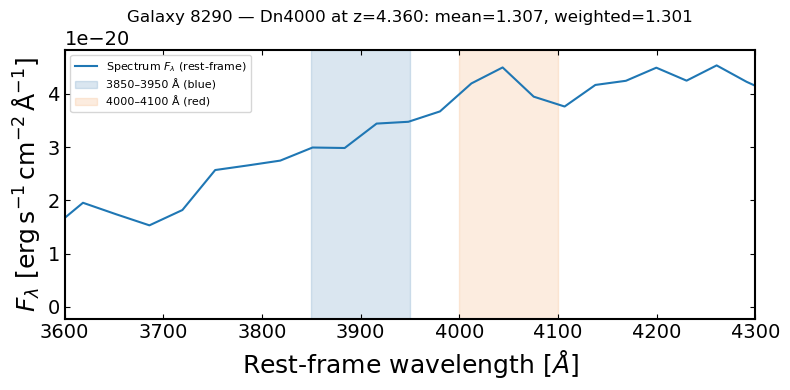

In [30]:
# ============================================================
# 2.5  Compute the 4000 Å break (Dn4000) for galaxy 8290
#      Dn4000 = <F_red>/<F_blue> using rest-frame windows:
#      blue = 3850–3950 Å, red = 4000–4100 Å
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# --- Adopt redshift ---
z = 4.360

# --- Rest-frame Dn4000 windows ---
blue = (3850.0, 3950.0)
red  = (4000.0, 4100.0)

# --- Use F_lambda from Section 2.1 ---
if ("flam_spec" not in globals()) or ("elam_spec" not in globals()):
    raise NameError("Missing flam_spec/elam_spec. Run Section 2.1 first.")

lam_obs = np.asarray(wave_A, dtype=float)
F = np.asarray(flam_spec, dtype=float)
E = np.asarray(elam_spec, dtype=float)

# --- Convert to rest frame ---
lam_rest = lam_obs / (1.0 + z)

# --- Clean and sort ---
m = np.isfinite(lam_rest) & np.isfinite(F) & np.isfinite(E) & (E > 0)
lamr = lam_rest[m]
Fr   = F[m]
Er   = E[m]

s = np.argsort(lamr)
lamr, Fr, Er = lamr[s], Fr[s], Er[s]

# --- Masks for blue/red windows ---
mb = (lamr >= blue[0]) & (lamr <= blue[1])
mr = (lamr >= red[0])  & (lamr <= red[1])

print(f"Rest-frame coverage: {lamr.min():.1f} – {lamr.max():.1f} Å (z={z:.3f})")
print(f"Points in blue window {blue[0]:.0f}–{blue[1]:.0f} Å: {mb.sum()}")
print(f"Points in red  window {red[0]:.0f}–{red[1]:.0f} Å: {mr.sum()}")

if mb.sum() < 2 or mr.sum() < 2:
    print("WARNING: Very few points in one/both windows; Dn4000 may be noisy.")

# --- Unweighted Dn4000 ---
Fb = np.mean(Fr[mb])
Frd = np.mean(Fr[mr])
Dn_mean = Frd / Fb

# --- Weighted Dn4000 ---
wb = 1.0 / Er[mb]**2
wr = 1.0 / Er[mr]**2
Fb_w = np.sum(wb * Fr[mb]) / np.sum(wb)
Fr_w = np.sum(wr * Fr[mr]) / np.sum(wr)
Dn_w = Fr_w / Fb_w

print(f"\nDn4000 (mean)     = {Dn_mean:.4f}")
print(f"Dn4000 (weighted) = {Dn_w:.4f}")

# --- Plot around the break ---
plt.figure(figsize=(8,4))
plt.plot(lamr, Fr, lw=1.5, color="tab:blue", label=r"Spectrum $F_\lambda$ (rest-frame)")
plt.axvspan(blue[0], blue[1], color="steelblue", alpha=0.20, label="3850–3950 Å (blue)")
plt.axvspan(red[0],  red[1],  color="sandybrown", alpha=0.20, label="4000–4100 Å (red)")

plt.xlim(3600, 4300)
plt.xlabel(r"Rest-frame wavelength [$\AA$]")
plt.ylabel(r"$F_\lambda\ [\mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}]$")
plt.title(f"Galaxy 8290 — Dn4000 at z={z:.3f}: mean={Dn_mean:.3f}, weighted={Dn_w:.3f}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 2.6 the resolution vs wavelength by using the provided NIRSpec spectrum

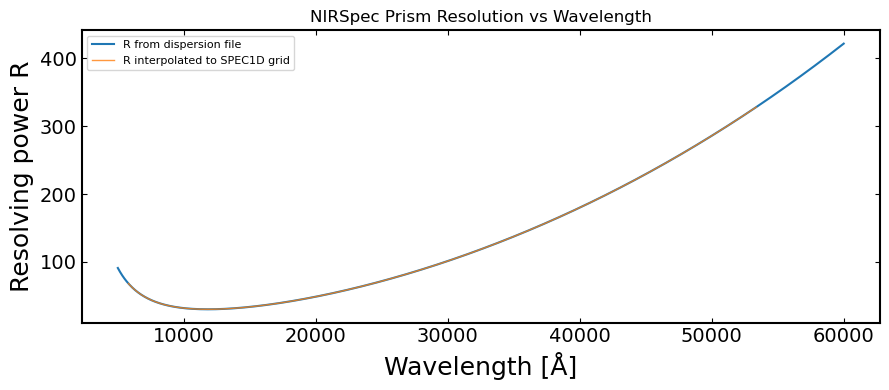

Dispersion-table coverage: 5000–60000 Å
R range (table): 30.1–421.6

At Balmer break λ_obs ≈ 19543 Å (z=4.360):
  R(λ) ≈ 46.9
  Δλ = λ/R ≈ 416.4 Å


In [31]:
# ============================================================
# 2.6  NIRSpec Prism spectral resolution R(λ) = λ/Δλ
#      Use the provided dispersion table and match it to the
#      wavelength grid of the provided SPEC1D spectrum.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# --- files ---
spec_file = "gds-barrufet-s67-v3_prism-clear_2198_8290.spec.fits"
disp_file = "jwst_nirspec_prism_disp.fits"

# --- load spectrum wavelength grid ---
with fits.open(spec_file) as hdul:
    spec = hdul["SPEC1D"].data
    wave_spec = np.asarray(spec["wave"], dtype=float)

# ensure Å
wave_spec_A = wave_spec.copy()
if np.nanmax(wave_spec_A) < 100:      # likely microns
    wave_spec_A *= 1e4
elif np.nanmax(wave_spec_A) < 1e5 and np.nanmin(wave_spec_A) < 1e3:
    # could be microns-ish; keep heuristic simple
    pass

# --- load dispersion table ---
with fits.open(disp_file) as hdul:
    tab = hdul["TABLE"].data
    wav = np.asarray(tab["WAVELENGTH"], dtype=float)
    Rtab = np.asarray(tab["R"], dtype=float)

# ensure Å for table wavelength too
wav_A = wav.copy()
if np.nanmedian(wav_A) < 100:   # microns
    wav_A *= 1e4

# clean + sort table
mt = np.isfinite(wav_A) & np.isfinite(Rtab) & (Rtab > 0)
wav_A = wav_A[mt]
Rtab  = Rtab[mt]
s = np.argsort(wav_A)
wav_A, Rtab = wav_A[s], Rtab[s]

# --- interpolate R onto the spectrum wavelength grid ---
ms = np.isfinite(wave_spec_A)
wA = wave_spec_A[ms]

# only interpolate where covered by the table
mcover = (wA >= wav_A.min()) & (wA <= wav_A.max())
R_on_spec = np.full_like(wA, np.nan, dtype=float)
R_on_spec[mcover] = np.interp(wA[mcover], wav_A, Rtab)

# --- compute Δλ = λ/R (Å) on the same grid (optional but useful) ---
dlambda = wA / R_on_spec

# --- plot R(λ) (table + on-spectrum grid) ---
plt.figure(figsize=(9,4))
plt.plot(wav_A, Rtab, lw=1.5, label="R from dispersion file")
plt.plot(wA, R_on_spec, lw=1.0, alpha=0.8, label="R interpolated to SPEC1D grid")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Resolving power R")
plt.title("NIRSpec Prism Resolution vs Wavelength")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- quick summary ---
Rmin = np.nanmin(Rtab); Rmax = np.nanmax(Rtab)
print(f"Dispersion-table coverage: {wav_A.min():.0f}–{wav_A.max():.0f} Å")
print(f"R range (table): {Rmin:.1f}–{Rmax:.1f}")

# --- print R and Δλ at Balmer break observed wavelength (from your z~4.36 estimate) ---
z_ref = 4.360
lam_balmer_obs = 3646.0 * (1.0 + z_ref)  # Å
if (lam_balmer_obs >= wav_A.min()) and (lam_balmer_obs <= wav_A.max()):
    R_balmer = float(np.interp(lam_balmer_obs, wav_A, Rtab))
    dlam_balmer = lam_balmer_obs / R_balmer
    print(f"\nAt Balmer break λ_obs ≈ {lam_balmer_obs:.0f} Å (z={z_ref:.3f}):")
    print(f"  R(λ) ≈ {R_balmer:.1f}")
    print(f"  Δλ = λ/R ≈ {dlam_balmer:.1f} Å")
else:
    print("\nBalmer-break wavelength is outside dispersion-table coverage.")

## 3 SED modelling of NIRCam photometry3 SED modelling of NIRCam photometry

### 3.1 — Photometry fit with delayed SFH + dust, free redshift (uniform prior)

Bagpipes max_redshift = 10.0
Number of bands: 10
Flux range [µJy]: 0.041588726043701174 1.1294166259765626
Median SNR: 9.999999568621286

Results loaded from pipes/posterior/phot_only_8290_delayed_zfree/8290.h5

Fitting not performed as results have already been loaded from pipes/posterior/phot_only_8290_delayed_zfree/8290.h5. To start over delete this file or change run.


Photometric redshift:
z_phot = 4.01 (+0.14/-0.35)
z 5–95% interval: [3.29, 4.28]

Reading posterior file: pipes/posterior/phot_only_8290_delayed_zfree/8290.h5
Visual overlay scale factor = 1.6100823345746618e+19
Post-scale obs/model median = 1.0054209196963528
Post-scale obs/model min/max = 0.18748783687005732 3.7016848938036935


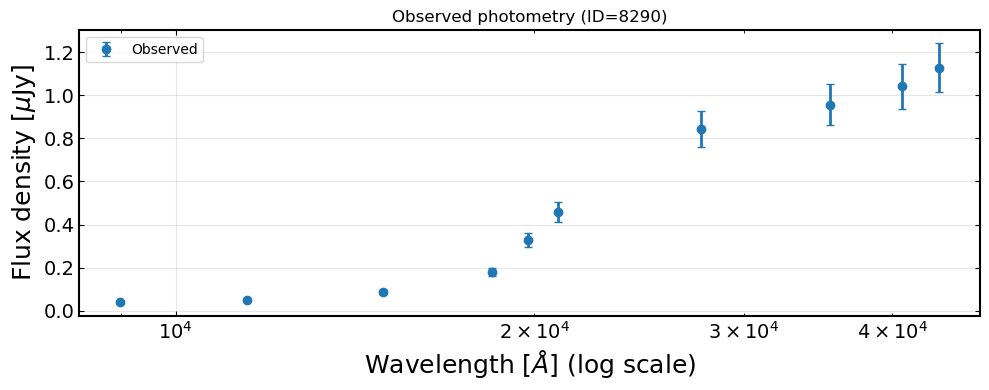

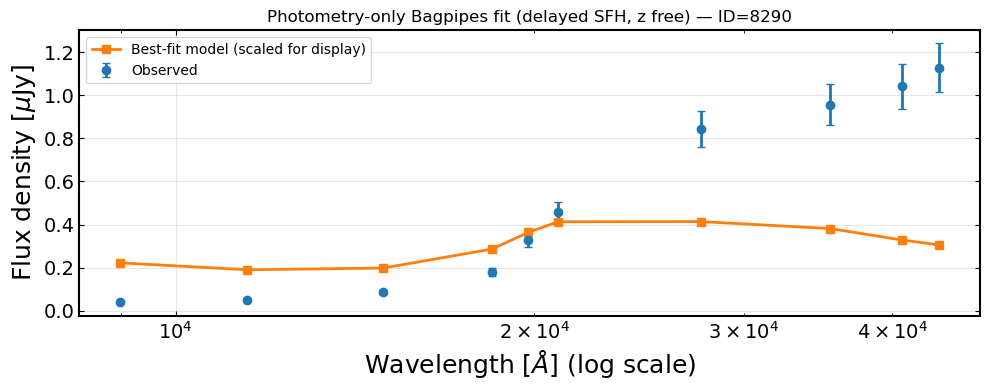

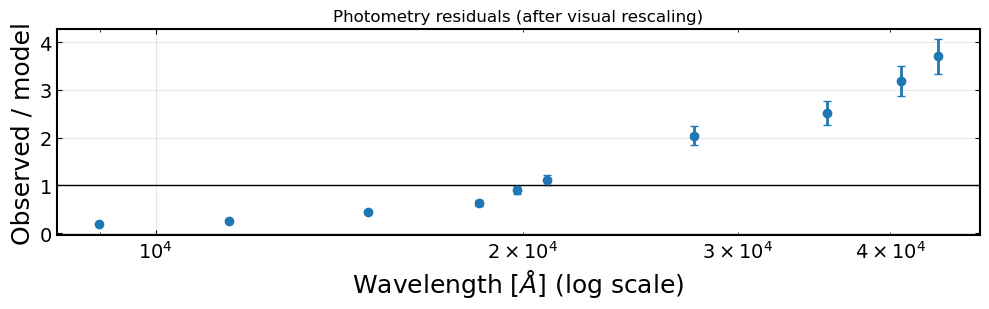

In [34]:
# ============================================================
# 3.1  Photometry-only Bagpipes fit
#      Delayed SFH + Calzetti dust + free redshift
#      Final version for your Bagpipes install
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import bagpipes as pipes
import bagpipes.config as cfg
import h5py
from pathlib import Path

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
ID = "8290"
run_name = f"phot_only_{ID}_delayed_zfree"
filter_list = np.loadtxt("filter_list.txt", dtype=str)

print("Bagpipes max_redshift =", cfg.max_redshift)

# ------------------------------------------------------------
# LOAD PHOTOMETRY
# course FITS stores fluxes in nJy -> convert to µJy
# ------------------------------------------------------------
def load_photometry(ID):
    t = Table.read(f"photometry/{ID}_photometry.fits", format="fits")
    flux_njy = np.array(t["mags_obs"][:len(filter_list)], dtype=float)
    err_njy  = np.array(t["mags_unc_obs"][:len(filter_list)], dtype=float)
    return np.c_[flux_njy*1e-3, err_njy*1e-3]   # nJy -> µJy

t_all = Table.read(f"photometry/{ID}_photometry.fits", format="fits")
wav_A = np.array(t_all["wavelength"][:len(filter_list)], dtype=float)
phot  = load_photometry(ID)

print("Number of bands:", phot.shape[0])
print("Flux range [µJy]:", np.nanmin(phot[:,0]), np.nanmax(phot[:,0]))
print("Median SNR:", np.nanmedian(phot[:,0] / phot[:,1]))

# ------------------------------------------------------------
# BUILD GALAXY OBJECT
# ------------------------------------------------------------
gal = pipes.galaxy(
    ID,
    load_photometry,
    photometry_exists=True,
    spectrum_exists=False,
    filt_list=filter_list,
    phot_units="mujy"
)

# ------------------------------------------------------------
# FIT INSTRUCTIONS
# ------------------------------------------------------------
fit_instructions = {
    "redshift": (0.0, 9.9),   # uniform prior
    "delayed": {
        "tau": (0.05, 10.0),
        "age": (0.01, 2.5),
        "massformed": (6.0, 13.5),
        "metallicity": (0.0, 2.5),
    },
    "dust": {
        "type": "Calzetti",
        "Av": (0.0, 4.0),
    },
    "nebular": {
        "logU": (-4.5, -1.0),
    }
}

# ------------------------------------------------------------
# RUN / LOAD FIT
# ------------------------------------------------------------
fit = pipes.fit(gal, fit_instructions, run=run_name)
fit.fit(sampler="nautilus", n_live=400, pool=4, verbose=True)

# ------------------------------------------------------------
# POSTERIOR SUMMARY
# ------------------------------------------------------------
samples = fit.posterior.samples

z = np.asarray(samples["redshift"], dtype=float)
z16, z50, z84 = np.percentile(z, [16, 50, 84])
z5, z95 = np.percentile(z, [5, 95])

print("\nPhotometric redshift:")
print(f"z_phot = {z50:.2f} (+{z84-z50:.2f}/-{z50-z16:.2f})")
print(f"z 5–95% interval: [{z5:.2f}, {z95:.2f}]")

# ------------------------------------------------------------
# BEST-FIT MODEL PHOTOMETRY
# ------------------------------------------------------------
# In your Bagpipes version the model photometry accessor is not
# directly in observed µJy normalisation, so we reconstruct the
# best-fit shape and then rescale for plotting only.
h5_path = Path(f"pipes/posterior/{run_name}/{ID}.h5")
print("\nReading posterior file:", h5_path)

with h5py.File(h5_path, "r") as f:
    theta_samples = np.array(f["samples2d"])
    lnlike = np.array(f["lnlike"])

imax = int(np.argmax(lnlike))
theta_best = theta_samples[imax]

fm = fit.fitted_model
_ = fm.lnlike(theta_best)   # populate fm.model_galaxy
model_phot_raw = np.array(fm.model_galaxy.photometry[:len(filter_list)], dtype=float)

# ------------------------------------------------------------
# RESCALE MODEL FOR VISUAL COMPARISON ONLY
# ------------------------------------------------------------
y = phot[:,0].astype(float)   # observed µJy
e = phot[:,1].astype(float)
m = model_phot_raw.astype(float)

good = np.isfinite(y) & np.isfinite(e) & np.isfinite(m) & (y > 0) & (e > 0) & (m > 0)

if good.sum() < 3:
    raise RuntimeError("Not enough valid points to compare model and data.")

# robust scale factor in log-space
snr = y / e
use = good & (snr > 3)
if use.sum() < 3:
    use = good

log_ratio = np.log10(y[use] / m[use])
med = np.median(log_ratio)
mad = 1.4826 * np.median(np.abs(log_ratio - med))
if mad > 0:
    keep = np.abs(log_ratio - med) < 3*mad
    log_ratio = log_ratio[keep]

scale = float(10**np.median(log_ratio))
model_phot = m * scale

ratio = y[good] / model_phot[good]
ratio_err = e[good] / model_phot[good]

print("Visual overlay scale factor =", scale)
print("Post-scale obs/model median =", np.median(ratio))
print("Post-scale obs/model min/max =", np.min(ratio), np.max(ratio))

# ------------------------------------------------------------
# FIGURE 1: OBSERVED PHOTOMETRY
# ------------------------------------------------------------
plt.figure(figsize=(10,4))
plt.errorbar(wav_A, y, yerr=e, fmt="o", capsize=3, label="Observed")
plt.xscale("log")
plt.xlabel(r"Wavelength [$\AA$] (log scale)")
plt.ylabel(r"Flux density [$\mu$Jy]")
plt.title(f"Observed photometry (ID={ID})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# FIGURE 2: BEST-FIT SHAPE OVERLAY
# ------------------------------------------------------------
plt.figure(figsize=(10,4))
plt.errorbar(wav_A, y, yerr=e, fmt="o", capsize=3, label="Observed")
plt.plot(wav_A, model_phot, "s-", label="Best-fit model (scaled for display)")
plt.xscale("log")
plt.xlabel(r"Wavelength [$\AA$] (log scale)")
plt.ylabel(r"Flux density [$\mu$Jy]")
plt.title(f"Photometry-only Bagpipes fit (delayed SFH, z free) — ID={ID}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# FIGURE 3: RESIDUALS
# ------------------------------------------------------------
plt.figure(figsize=(10,3.2))
plt.errorbar(wav_A[good], ratio, yerr=ratio_err, fmt="o", capsize=3)
plt.axhline(1.0, lw=1, color="black")
plt.xscale("log")
plt.xlabel(r"Wavelength [$\AA$] (log scale)")
plt.ylabel("Observed / model")
plt.title("Photometry residuals (after visual rescaling)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 - UVJ classification + sSFR criterion

Available posterior keys:
['delayed:age', 'delayed:massformed', 'delayed:metallicity', 'delayed:tau', 'dust:Av', 'formed_mass', 'mass_weighted_age', 'mass_weighted_zmet', 'nebular:logU', 'nsfr', 'redshift', 'sfh', 'sfr', 'ssfr', 'stellar_mass', 'tform', 'tquench']

=== UVJ classification ===
Posterior median: V-J = 1.131 (+0.119/-0.071)
Posterior median: U-V = 1.368 (+0.055/-0.062)
UVJ quiescent? (median point) = False
P(quiescent) from UVJ posterior = 0.073

=== sSFR criterion ===
z_med = 4.007
t_age(z_med) = 1.534e+09 yr
sSFR threshold = 0.2 / t_age = 1.304e-10 yr^-1
median log10(sSFR/yr^-1) = -8.653
median sSFR = 2.223e-09 yr^-1
sSFR quiescent? (median point) = False
P(quiescent) from sSFR posterior = 0.000


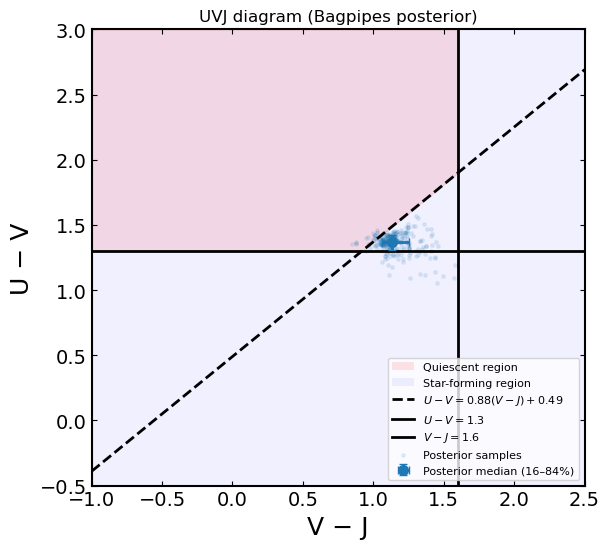

In [36]:
# ============================================================
# 3.2  UVJ classification + sSFR criterion
#      Works even if posterior.samples does not contain "uvj"
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from astropy.cosmology import Planck18
import h5py
from pathlib import Path

# ------------------------------------------------------------
# Basic posterior dictionary
# ------------------------------------------------------------
samples = fit.posterior.samples

print("Available posterior keys:")
print(sorted(samples.keys()))

# ------------------------------------------------------------
# Load raw posterior parameter vectors from saved fit
# ------------------------------------------------------------
h5_path = Path(f"pipes/posterior/{run_name}/{ID}.h5")
with h5py.File(h5_path, "r") as f:
    theta_samples = np.array(f["samples2d"])
    lnlike = np.array(f["lnlike"])

# ------------------------------------------------------------
# Reconstruct UVJ from posterior samples
# ------------------------------------------------------------
# Use a subset to keep things fast
nsamp = min(300, theta_samples.shape[0])

rng = np.random.default_rng(42)
idx = rng.choice(theta_samples.shape[0], size=nsamp, replace=False)

fm = fit.fitted_model

U_list, V_list, J_list = [], [], []

for i in idx:
    theta = theta_samples[i]
    _ = fm.lnlike(theta)   # updates fm.model_galaxy
    try:
        U, V, J = fm.model_galaxy.uvj
        U_list.append(float(U))
        V_list.append(float(V))
        J_list.append(float(J))
    except Exception:
        continue

U_s = np.array(U_list)
V_s = np.array(V_list)
J_s = np.array(J_list)

if len(U_s) == 0:
    raise RuntimeError("Could not reconstruct UVJ colours from posterior samples.")

UV_s = U_s - V_s
VJ_s = V_s - J_s

# ------------------------------------------------------------
# Percentiles
# ------------------------------------------------------------
def pct(x):
    x = np.asarray(x, dtype=float)
    return np.percentile(x, [16, 50, 84])

UV16, UV50, UV84 = pct(UV_s)
VJ16, VJ50, VJ84 = pct(VJ_s)

# ------------------------------------------------------------
# UVJ quiescent classification
# ------------------------------------------------------------
is_q_uvj_samples = (UV_s > 0.88*VJ_s + 0.49) & (UV_s > 1.3) & (VJ_s < 1.6)
p_quiescent_uvj = np.mean(is_q_uvj_samples)

is_q_uvj_median = (UV50 > 0.88*VJ50 + 0.49) and (UV50 > 1.3) and (VJ50 < 1.6)

# ------------------------------------------------------------
# sSFR criterion
# ------------------------------------------------------------
# Preferred: use posterior ssfr if available
if "ssfr" in samples:
    ssfr_log10 = np.asarray(samples["ssfr"], dtype=float)

# Fallback: compute from posterior sfr and stellar_mass if available
elif ("sfr" in samples) and ("stellar_mass" in samples):
    sfr = np.asarray(samples["sfr"], dtype=float)                # assumed linear Msun/yr
    logM = np.asarray(samples["stellar_mass"], dtype=float)      # assumed log10(M*/Msun)
    ssfr_log10 = np.log10(np.clip(sfr, 1e-30, None)) - logM

else:
    raise KeyError(
        "No 'ssfr' key found, and could not build sSFR from 'sfr' and 'stellar_mass'. "
        "Run print(sorted(samples.keys())) and send me the output if this happens."
    )

ssfr = 10**ssfr_log10

# use median redshift from posterior
z_s = np.asarray(samples["redshift"], dtype=float)
z_med = np.median(z_s)

t_age_yr = Planck18.age(z_med).to("yr").value
ssfr_thresh = 0.2 / t_age_yr

is_q_ssfr_samples = ssfr < ssfr_thresh
p_quiescent_ssfr = np.mean(is_q_ssfr_samples)

is_q_ssfr_median = (10**np.median(ssfr_log10)) < ssfr_thresh

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------
print("\n=== UVJ classification ===")
print(f"Posterior median: V-J = {VJ50:.3f} (+{VJ84-VJ50:.3f}/-{VJ50-VJ16:.3f})")
print(f"Posterior median: U-V = {UV50:.3f} (+{UV84-UV50:.3f}/-{UV50-UV16:.3f})")
print(f"UVJ quiescent? (median point) = {is_q_uvj_median}")
print(f"P(quiescent) from UVJ posterior = {p_quiescent_uvj:.3f}")

print("\n=== sSFR criterion ===")
print(f"z_med = {z_med:.3f}")
print(f"t_age(z_med) = {t_age_yr:.3e} yr")
print(f"sSFR threshold = 0.2 / t_age = {ssfr_thresh:.3e} yr^-1")
print(f"median log10(sSFR/yr^-1) = {np.median(ssfr_log10):.3f}")
print(f"median sSFR = {10**np.median(ssfr_log10):.3e} yr^-1")
print(f"sSFR quiescent? (median point) = {is_q_ssfr_median}")
print(f"P(quiescent) from sSFR posterior = {p_quiescent_ssfr:.3f}")

# ------------------------------------------------------------
# UVJ diagram
# ------------------------------------------------------------
xmin = min(VJ16 - 0.4, -1.0)
xmax = max(VJ84 + 0.4,  2.5)
ymin = min(UV16 - 0.4, -0.5)
ymax = max(UV84 + 0.6,  3.0)

x = np.linspace(xmin, xmax, 500)
y_diag = 0.88*x + 0.49
y_h = 1.3
x_v = 1.6

plt.figure(figsize=(6.2, 5.6))

# Star-forming background
plt.fill_between(x, ymin, ymax, color="blue", alpha=0.06)

# Quiescent wedge
x_shade = x[x <= x_v]
y_lower = np.maximum(0.88*x_shade + 0.49, y_h)
plt.fill_between(x_shade, y_lower, ymax, color="red", alpha=0.10)

# Boundaries
plt.plot(x, y_diag, "k--", lw=2, label=r"$U-V = 0.88(V-J)+0.49$")
plt.axhline(y_h, color="k", lw=2, label=r"$U-V = 1.3$")
plt.axvline(x_v, color="k", lw=2, label=r"$V-J = 1.6$")

# Posterior cloud
plt.scatter(VJ_s, UV_s, s=6, alpha=0.10, label="Posterior samples")

# Median point + uncertainties
plt.errorbar(
    VJ50, UV50,
    xerr=[[VJ50 - VJ16], [VJ84 - VJ50]],
    yerr=[[UV50 - UV16], [UV84 - UV50]],
    fmt="o", ms=7, capsize=3, zorder=5,
    label="Posterior median (16–84%)"
)

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.xlabel("V − J")
plt.ylabel("U − V")
plt.title("UVJ diagram (Bagpipes posterior)")

region_handles = [
    Patch(facecolor="red", alpha=0.10, label="Quiescent region"),
    Patch(facecolor="blue", alpha=0.06, label="Star-forming region"),
]

line_handles, line_labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=region_handles + line_handles, loc="lower right", fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

### 3.3 - Compare different SFH prescriptions


===== Running delayed model =====

Results loaded from pipes/posterior/phot_only_8290_delayed_zfree/8290.h5

Fitting not performed as results have already been loaded from pipes/posterior/phot_only_8290_delayed_zfree/8290.h5. To start over delete this file or change run.


===== Running exponential model =====

Results loaded from pipes/posterior/phot_only_8290_exponential_zfree/8290.h5

Fitting not performed as results have already been loaded from pipes/posterior/phot_only_8290_exponential_zfree/8290.h5. To start over delete this file or change run.


===== Running dblplaw model =====

Results loaded from pipes/posterior/phot_only_8290_dblplaw_zfree/8290.h5

Fitting not performed as results have already been loaded from pipes/posterior/phot_only_8290_dblplaw_zfree/8290.h5. To start over delete this file or change run.



/Users/alberto/miniforge3/envs/galaxy_course/lib/python3.13/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1



===== Running burst model =====

Results loaded from pipes/posterior/phot_only_8290_burst_zfree/8290.h5

Fitting not performed as results have already been loaded from pipes/posterior/phot_only_8290_burst_zfree/8290.h5. To start over delete this file or change run.


=== SFH comparison summary ===
Model        z_phot         U-V      V-J      UVJ?   Pq(UVJ)   log sSFR   sSFR?   Pq(sSFR)
delayed     4.01 (+0.15/-0.30)   1.367   1.134   False   0.044     -8.656   False   0.000
exponential 4.01 (+0.10/-0.11)   1.376   1.079   False   0.152     -8.882   False   0.000
dblplaw     4.26 (+0.10/-0.11)   1.332   0.670   True    0.780     -30.000   True    0.998
burst       4.25 (+0.11/-0.11)   1.335   0.667   True    0.784     -30.000   True    1.000


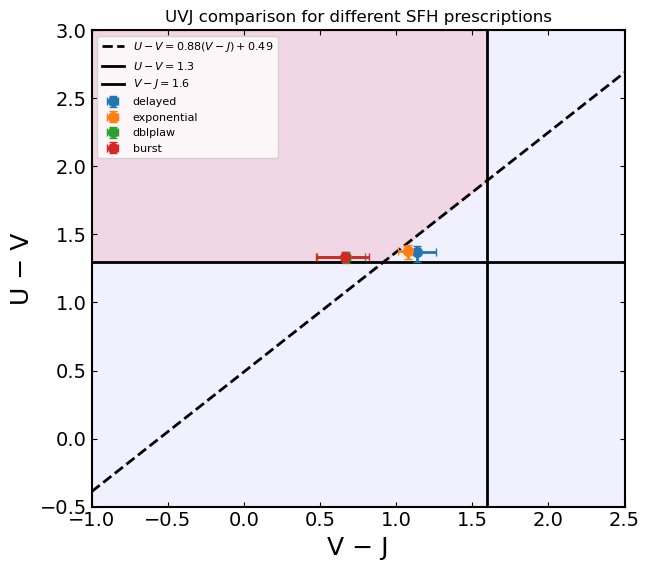

In [38]:
# ============================================================
# 3.3  Compare different SFH prescriptions
#      Robust version with safer sSFR handling
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.cosmology import Planck18
import bagpipes as pipes
import h5py
from pathlib import Path

ID = "8290"
filter_list = np.loadtxt("filter_list.txt", dtype=str)

# ------------------------------------------------------------
# Load photometry (nJy -> µJy)
# ------------------------------------------------------------
def load_photometry(ID):
    t = Table.read(f"photometry/{ID}_photometry.fits", format="fits")
    flux_njy = np.array(t["mags_obs"][:len(filter_list)], dtype=float)
    err_njy  = np.array(t["mags_unc_obs"][:len(filter_list)], dtype=float)
    return np.c_[flux_njy * 1e-3, err_njy * 1e-3]

# wavelength array for plotting
t_all = Table.read(f"photometry/{ID}_photometry.fits", format="fits")
wav_A = np.array(t_all["wavelength"][:len(filter_list)], dtype=float)
phot  = load_photometry(ID)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def pct(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return np.percentile(x, [16, 50, 84])

def classify_uvj(UV, VJ):
    return (UV > 0.88 * VJ + 0.49) and (UV > 1.3) and (VJ < 1.6)

def get_uvj_from_fit(fit, run_name, nsamp=250, seed=42):
    h5_path = Path(f"pipes/posterior/{run_name}/{ID}.h5")
    with h5py.File(h5_path, "r") as f:
        theta_samples = np.array(f["samples2d"])

    rng = np.random.default_rng(seed)
    nsamp = min(nsamp, theta_samples.shape[0])
    idx = rng.choice(theta_samples.shape[0], size=nsamp, replace=False)

    fm = fit.fitted_model
    U_list, V_list, J_list = [], [], []

    for i in idx:
        _ = fm.lnlike(theta_samples[i])
        try:
            U, V, J = fm.model_galaxy.uvj
            U_list.append(float(U))
            V_list.append(float(V))
            J_list.append(float(J))
        except Exception:
            continue

    U_s = np.array(U_list)
    V_s = np.array(V_list)
    J_s = np.array(J_list)

    UV_s = U_s - V_s
    VJ_s = V_s - J_s
    return UV_s, VJ_s

def get_ssfr_log10(samples, sfh_name):
    """
    Robustly compute log10(sSFR/yr^-1).
    Prefer sfr + stellar_mass if available.
    Fall back to ssfr only if needed.
    """
    if ("sfr" in samples) and ("stellar_mass" in samples):
        sfr = np.asarray(samples["sfr"], dtype=float)                  # Msun/yr
        logM = np.asarray(samples["stellar_mass"], dtype=float)        # log10(M*/Msun)

        # clip SFR to avoid log10(0) or nonsense negatives
        sfr = np.clip(sfr, 1e-30, None)
        ssfr_log10 = np.log10(sfr) - logM

    elif "ssfr" in samples:
        ssfr_log10 = np.asarray(samples["ssfr"], dtype=float)

    else:
        raise KeyError(f"No ssfr info available for {sfh_name}")

    # remove pathological values
    ssfr_log10 = np.asarray(ssfr_log10, dtype=float)
    ssfr_log10[~np.isfinite(ssfr_log10)] = np.nan

    # clip absurd underflows/overflows for cleaner summaries
    ssfr_log10 = np.clip(ssfr_log10, -30, 5)

    return ssfr_log10

# ------------------------------------------------------------
# SFH model definitions
# ------------------------------------------------------------
sfh_models = {
    "delayed": {
        "delayed": {
            "tau": (0.05, 10.0),
            "age": (0.01, 2.5),
            "massformed": (6.0, 13.5),
            "metallicity": (0.0, 2.5),
        }
    },
    "exponential": {
        "exponential": {
            "tau": (0.05, 10.0),
            "age": (0.01, 2.5),
            "massformed": (6.0, 13.5),
            "metallicity": (0.0, 2.5),
        }
    },
    "dblplaw": {
        "dblplaw": {
            "tau": (0.01, 15.0),
            "alpha": (0.01, 1000.0),
            "beta": (0.01, 1000.0),
            "massformed": (6.0, 13.5),
            "metallicity": (0.0, 2.5),
        }
    },
    "burst": {
        "burst": {
            "age": (0.01, 2.5),
            "massformed": (6.0, 13.5),
            "metallicity": (0.0, 2.5),
        }
    },
}

# ------------------------------------------------------------
# Run fits
# ------------------------------------------------------------
results = {}

for sfh_name, sfh_block in sfh_models.items():

    print(f"\n===== Running {sfh_name} model =====")

    gal = pipes.galaxy(
        ID,
        load_photometry,
        photometry_exists=True,
        spectrum_exists=False,
        filt_list=filter_list,
        phot_units="mujy"
    )

    fit_instructions = {
        "redshift": (0.0, 9.9),
        "dust": {
            "type": "Calzetti",
            "Av": (0.0, 4.0),
        },
        "nebular": {
            "logU": (-4.5, -1.0),
        },
    }
    fit_instructions.update(sfh_block)

    run_name = f"phot_only_{ID}_{sfh_name}_zfree"

    fit = pipes.fit(gal, fit_instructions, run=run_name)
    fit.fit(sampler="nautilus", n_live=400, pool=4, verbose=True)

    samples = fit.posterior.samples

    # redshift posterior
    z_s = np.asarray(samples["redshift"], dtype=float)
    z16, z50, z84 = np.percentile(z_s, [16, 50, 84])

    # robust sSFR
    ssfr_log10 = get_ssfr_log10(samples, sfh_name)
    ssfr_log10_finite = ssfr_log10[np.isfinite(ssfr_log10)]

    z_med = np.median(z_s)
    t_age_yr = Planck18.age(z_med).to("yr").value
    ssfr_thresh = 0.2 / t_age_yr
    log_ssfr_thresh = np.log10(ssfr_thresh)

    p_quiescent_ssfr = np.mean(ssfr_log10_finite < log_ssfr_thresh)
    is_q_ssfr_med = np.median(ssfr_log10_finite) < log_ssfr_thresh

    # UVJ reconstructed from posterior
    UV_s, VJ_s = get_uvj_from_fit(fit, run_name, nsamp=250, seed=42)
    UV16, UV50, UV84 = pct(UV_s)
    VJ16, VJ50, VJ84 = pct(VJ_s)

    is_q_uvj_med = classify_uvj(UV50, VJ50)
    p_quiescent_uvj = np.mean((UV_s > 0.88 * VJ_s + 0.49) & (UV_s > 1.3) & (VJ_s < 1.6))

    results[sfh_name] = {
        "z50": z50, "z16": z16, "z84": z84,
        "UV50": UV50, "UV16": UV16, "UV84": UV84,
        "VJ50": VJ50, "VJ16": VJ16, "VJ84": VJ84,
        "is_q_uvj_med": is_q_uvj_med,
        "p_quiescent_uvj": p_quiescent_uvj,
        "logssfr50": np.median(ssfr_log10_finite),
        "is_q_ssfr_med": is_q_ssfr_med,
        "p_quiescent_ssfr": p_quiescent_ssfr,
        "ssfr_thresh": ssfr_thresh,
    }

# ------------------------------------------------------------
# Print summary table
# ------------------------------------------------------------
print("\n=== SFH comparison summary ===")
print("Model        z_phot         U-V      V-J      UVJ?   Pq(UVJ)   log sSFR   sSFR?   Pq(sSFR)")
for name, r in results.items():
    print(f"{name:11s} "
          f"{r['z50']:.2f} (+{r['z84']-r['z50']:.2f}/-{r['z50']-r['z16']:.2f})   "
          f"{r['UV50']:.3f}   {r['VJ50']:.3f}   "
          f"{str(r['is_q_uvj_med']):5s}   {r['p_quiescent_uvj']:.3f}     "
          f"{r['logssfr50']:.3f}   {str(r['is_q_ssfr_med']):5s}   {r['p_quiescent_ssfr']:.3f}")

# ------------------------------------------------------------
# UVJ diagram with model medians
# ------------------------------------------------------------
plt.figure(figsize=(6.6, 5.8))

xmin, xmax = -1.0, 2.5
ymin, ymax = -0.5, 3.0
x = np.linspace(xmin, xmax, 500)

plt.fill_between(x, ymin, ymax, color="blue", alpha=0.06)
x_shade = x[x <= 1.6]
y_lower = np.maximum(0.88 * x_shade + 0.49, 1.3)
plt.fill_between(x_shade, y_lower, ymax, color="red", alpha=0.10)

plt.plot(x, 0.88 * x + 0.49, "k--", lw=2, label=r"$U-V = 0.88(V-J)+0.49$")
plt.axhline(1.3, color="k", lw=2, label=r"$U-V = 1.3$")
plt.axvline(1.6, color="k", lw=2, label=r"$V-J = 1.6$")

color_map = {
    "delayed": "tab:blue",
    "exponential": "tab:orange",
    "dblplaw": "tab:green",
    "burst": "tab:red",
}

for name, r in results.items():
    plt.errorbar(
        r["VJ50"], r["UV50"],
        xerr=[[r["VJ50"] - r["VJ16"]], [r["VJ84"] - r["VJ50"]]],
        yerr=[[r["UV50"] - r["UV16"]], [r["UV84"] - r["UV50"]]],
        fmt="o", ms=7, capsize=3, color=color_map[name], label=name
    )

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.xlabel("V − J")
plt.ylabel("U − V")
plt.title("UVJ comparison for different SFH prescriptions")
plt.legend(fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

### 3.4 — Model comparison using the Bayesian Information Criterion (BIC)

In [39]:
# ============================================================
# 3.4  Model comparison using the Bayesian Information Criterion
# ============================================================

import numpy as np
import h5py
from pathlib import Path

# number of photometric points
n_data = len(filter_list)

print("Number of photometric bands:", n_data)

# ------------------------------------------------------------
# number of free parameters for each model
# ------------------------------------------------------------
# redshift + dust + nebular + SFH parameters

k_params = {
    "delayed": 6,       # z, tau, age, massformed, metallicity, Av (+ nebular counted below)
    "exponential": 6,
    "dblplaw": 7,
    "burst": 5,
}

# add nebular parameter
for k in k_params:
    k_params[k] += 1   # nebular:logU


# ------------------------------------------------------------
# read likelihoods and compute BIC
# ------------------------------------------------------------
bic_results = {}

for model in k_params:

    run_name = f"phot_only_{ID}_{model}_zfree"
    h5_path = Path(f"pipes/posterior/{run_name}/{ID}.h5")

    with h5py.File(h5_path, "r") as f:
        lnlike = np.array(f["lnlike"])

    lnL_max = np.max(lnlike)

    k = k_params[model]

    BIC = k * np.log(n_data) - 2 * lnL_max

    bic_results[model] = {
        "lnLmax": lnL_max,
        "k": k,
        "BIC": BIC
    }


# ------------------------------------------------------------
# print results
# ------------------------------------------------------------
print("\n=== BIC comparison ===")
print("Model        k     lnLmax        BIC")

for model, r in bic_results.items():
    print(f"{model:11s}  {r['k']:2d}   {r['lnLmax']:8.2f}   {r['BIC']:10.2f}")


# ------------------------------------------------------------
# determine preferred model
# ------------------------------------------------------------
best_model = min(bic_results, key=lambda x: bic_results[x]["BIC"])

print("\nPreferred model according to BIC:", best_model)

# BIC differences
best_BIC = bic_results[best_model]["BIC"]

print("\nΔBIC relative to best model:")

for model, r in bic_results.items():
    dBIC = r["BIC"] - best_BIC
    print(f"{model:11s}  ΔBIC = {dBIC:6.2f}")

Number of photometric bands: 10

=== BIC comparison ===
Model        k     lnLmax        BIC
delayed       7     460.76      -905.41
exponential   7     460.97      -905.81
dblplaw       8     465.45      -912.48
burst         6     465.41      -917.01

Preferred model according to BIC: burst

ΔBIC relative to best model:
delayed      ΔBIC =  11.60
exponential  ΔBIC =  11.20
dblplaw      ΔBIC =   4.53
burst        ΔBIC =   0.00


### 3.5 — Formation and quenching times for the preferred model

In [40]:
# ============================================================
# 3.5  Formation and quenching times for the preferred model
#      Preferred model from BIC = burst
# ============================================================

import numpy as np
from astropy.cosmology import Planck18

# ------------------------------------------------------------
# Re-open preferred fit (burst)
# ------------------------------------------------------------
preferred_model = "burst"
run_name = f"phot_only_{ID}_{preferred_model}_zfree"

gal = pipes.galaxy(
    ID,
    load_photometry,
    photometry_exists=True,
    spectrum_exists=False,
    filt_list=filter_list,
    phot_units="mujy"
)

fit_instructions = {
    "redshift": (0.0, 9.9),
    "dust": {"type": "Calzetti", "Av": (0.0, 4.0)},
    "nebular": {"logU": (-4.5, -1.0)},
    "burst": {
        "age": (0.01, 2.5),
        "massformed": (6.0, 13.5),
        "metallicity": (0.0, 2.5),
    }
}

fit_burst = pipes.fit(gal, fit_instructions, run=run_name)
fit_burst.fit(sampler="nautilus", n_live=400, pool=4, verbose=True)

samples = fit_burst.posterior.samples

print("Available posterior keys:")
print(sorted(samples.keys()))

# ------------------------------------------------------------
# Extract tform and tquench
# Prefer direct posterior keys if available
# ------------------------------------------------------------
if "tform" in samples:
    tform = np.asarray(samples["tform"], dtype=float)
else:
    raise KeyError("No 'tform' key found in posterior samples.")

if "tquench" in samples:
    tquench = np.asarray(samples["tquench"], dtype=float)
else:
    raise KeyError("No 'tquench' key found in posterior samples.")

# clean
tform = tform[np.isfinite(tform)]
tquench = tquench[np.isfinite(tquench)]

def pct(x):
    return np.percentile(x, [16, 50, 84])

tf16, tf50, tf84 = pct(tform)
tq16, tq50, tq84 = pct(tquench)

print("\n=== Preferred model: burst ===")
print(f"t_form    = {tf50:.3f} (+{tf84-tf50:.3f}/-{tf50-tf16:.3f}) Gyr")
print(f"t_quench  = {tq50:.3f} (+{tq84-tq50:.3f}/-{tq50-tq16:.3f}) Gyr")

# ------------------------------------------------------------
# Convert to redshift equivalents if possible
# Bagpipes times are usually cosmic times (Gyr after Big Bang)
# ------------------------------------------------------------
z_med = np.median(np.asarray(samples["redshift"], dtype=float))
t_obs = Planck18.age(z_med).value   # Gyr, cosmic time at observation

print(f"\nObserved redshift median z = {z_med:.3f}")
print(f"Cosmic time at observation = {t_obs:.3f} Gyr")

# formation/quenching lookback relative to observed epoch
dt_form_obs = t_obs - tf50
dt_quench_obs = t_obs - tq50

print(f"Time between formation and observation ≈ {dt_form_obs:.3f} Gyr")
print(f"Time between quenching and observation ≈ {dt_quench_obs:.3f} Gyr")
print(f"Quenching after formation lasted ≈ {tq50 - tf50:.3f} Gyr")

# ------------------------------------------------------------
# Optional: convert cosmic times to approximate redshifts
# ------------------------------------------------------------
# We invert age(z) numerically on a grid
z_grid = np.linspace(0.01, 20.0, 20000)
age_grid = np.array([Planck18.age(z).value for z in z_grid])  # Gyr

# age decreases with z, so reverse for interpolation
z_form = np.interp(tf50, age_grid[::-1], z_grid[::-1])
z_quench = np.interp(tq50, age_grid[::-1], z_grid[::-1])

print(f"\nApproximate formation redshift  z_form   ≈ {z_form:.2f}")
print(f"Approximate quenching redshift  z_quench ≈ {z_quench:.2f}")

# ------------------------------------------------------------
# Short interpretation helper
# ------------------------------------------------------------
print("\nInterpretation:")
print("- t_form gives the cosmic time when the bulk of the stellar population formed.")
print("- t_quench gives the cosmic time when star formation effectively shut down.")
print("- If t_quench is much earlier than the observation time, the galaxy has been quiescent for a significant period.")
print("- For the preferred burst-like SFH, rapid formation followed by early quenching is consistent with a short, intense episode of star formation.")
print("- This kind of SFH can be associated with fast quenching mechanisms such as AGN feedback, gas exhaustion after a compact starburst, or strong outflows.")


Results loaded from pipes/posterior/phot_only_8290_burst_zfree/8290.h5

Fitting not performed as results have already been loaded from pipes/posterior/phot_only_8290_burst_zfree/8290.h5. To start over delete this file or change run.

Available posterior keys:
['burst:age', 'burst:massformed', 'burst:metallicity', 'dust:Av', 'formed_mass', 'mass_weighted_age', 'mass_weighted_zmet', 'nebular:logU', 'nsfr', 'redshift', 'sfh', 'sfr', 'ssfr', 'stellar_mass', 'tform', 'tquench']

=== Preferred model: burst ===
t_form    = 1.110 (+0.096/-0.121) Gyr
t_quench  = 1.110 (+0.096/-0.121) Gyr

Observed redshift median z = 4.250
Cosmic time at observation = 1.430 Gyr
Time between formation and observation ≈ 0.319 Gyr
Time between quenching and observation ≈ 0.319 Gyr
Quenching after formation lasted ≈ 0.000 Gyr

Approximate formation redshift  z_form   ≈ 5.22
Approximate quenching redshift  z_quench ≈ 5.22

Interpretation:
- t_form gives the cosmic time when the bulk of the stellar population formed